# **Taking the Swing: Momentum in Tennis**


---



---
Written By:
- Riechie
- Ferell Aaron Wirjanto
- Ryuki Ranawidjaja

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# **Data Understanding**

In [ ]:
explanation_data = pd.read_csv('/content/drive/MyDrive/MCM 2024/data_dictionary.csv')
explanation_data

,variables,explanation,example
0,match_id,match identification,"2023-wimbledon-1701 (""7"" is the round, and ""01..."
1,player1,first and last name of the first player,Carlos Alcaraz
2,player2,first and last name of the second player,Novak Djokovic
3,elapsed_time,time elapsed since start of first point to sta...,0:10:27
4,set_no,set number in match,"1, 2, 3, 4, or 5"
5,game_no,game number in set,"1, 2, ...,7"
6,point_no,point number in game,"1, 2, 3... etc."
7,p1_sets,sets won by player 1,"0, 1, or 2"
8,p2_sets,sets won by player 2,"0, 1, or 2"
9,p1_games,games won by player 1 in current set,"0, 1,...,6"


In [ ]:
player_serve_data = pd.read_csv('/content/drive/MyDrive/MCM 2024/PlayersServe_.csv')
player_serve_data

,Name,Total Service Points Won,Total Return Points Won
0,Carlos Alcaraz,0.66,0.42
1,Andrey Rublev,0.65,0.39
2,Jannik Sinner,0.66,0.40
3,Daniil Medvedev,0.66,0.40
4,Christopher Eubanks,0.66,0.30
5,Alejandro Davidovich Fokina,0.61,0.39
6,Jiri Lehecka,0.64,0.35
7,Daniel Elahi Galan,0.61,0.37
8,Denis Shapovalov,0.66,0.36
9,Grigor Dimitrov,0.66,0.37


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/MCM 2024/Wimbledon_featured_matches.csv')
data

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,p2_break_pt_won,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth
0,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:00:00,1,1,1,0,0,0,...,0,0,0,6.000,7.840,2,95.0,BC,NCTL,ND
1,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:00:38,1,1,2,0,0,0,...,0,0,0,5.253,7.094,1,118.0,B,CTL,ND
2,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:01:01,1,1,3,0,0,0,...,0,0,0,13.800,19.808,4,120.0,B,NCTL,D
3,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:01:31,1,1,4,0,0,0,...,0,0,0,51.108,75.631,13,130.0,BW,CTL,D
4,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:02:21,1,1,5,0,0,0,...,0,0,0,0.649,0.813,1,112.0,W,NCTL,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7279,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:39:58,5,10,330,2,2,5,...,0,0,0,38.620,50.971,11,123.0,C,NCTL,D
7280,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:40:43,5,10,331,2,2,5,...,0,0,0,17.533,27.766,5,114.0,W,NCTL,ND
7281,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:20,5,10,332,2,2,5,...,0,0,0,10.882,18.328,4,124.0,W,NCTL,D
7282,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:52,5,10,333,2,2,5,...,0,0,0,7.893,10.537,1,130.0,C,NCTL,D


Checking how many matches are in contained in this dataset

In [ ]:
data['match_id'].value_counts()

2023-wimbledon-1304    337
2023-wimbledon-1701    334
2023-wimbledon-1306    332
2023-wimbledon-1407    331
2023-wimbledon-1310    318
2023-wimbledon-1301    300
2023-wimbledon-1313    290
2023-wimbledon-1404    286
2023-wimbledon-1502    283
2023-wimbledon-1312    275
2023-wimbledon-1402    274
2023-wimbledon-1408    271
2023-wimbledon-1305    246
2023-wimbledon-1307    232
2023-wimbledon-1401    225
2023-wimbledon-1504    217
2023-wimbledon-1405    215
2023-wimbledon-1309    213
2023-wimbledon-1602    202
2023-wimbledon-1302    201
2023-wimbledon-1315    198
2023-wimbledon-1406    195
2023-wimbledon-1503    193
2023-wimbledon-1308    190
2023-wimbledon-1501    189
2023-wimbledon-1314    185
2023-wimbledon-1311    170
2023-wimbledon-1316    167
2023-wimbledon-1601    159
2023-wimbledon-1303    134
2023-wimbledon-1403    122
Name: match_id, dtype: int64

In [ ]:
data['match_id'].nunique()

31

Checking shape of the data

In [ ]:
data.shape

(7284, 46)

In [ ]:
data.isnull().any()

match_id              False
player1               False
player2               False
elapsed_time          False
set_no                False
game_no               False
point_no              False
p1_sets               False
p2_sets               False
p1_games              False
p2_games              False
p1_score              False
p2_score              False
server                False
serve_no              False
point_victor          False
p1_points_won         False
p2_points_won         False
game_victor           False
set_victor            False
p1_ace                False
p2_ace                False
p1_winner             False
p2_winner             False
winner_shot_type      False
p1_double_fault       False
p2_double_fault       False
p1_unf_err            False
p2_unf_err            False
p1_net_pt             False
p2_net_pt             False
p1_net_pt_won         False
p2_net_pt_won         False
p1_break_pt           False
p2_break_pt           False
p1_break_pt_won     

In [ ]:
data.isnull().sum().sum()

2169

# **Data Processing**

## Converting Player Scores

In [ ]:
data.loc[data['p1_score'] == 'AD', 'p2_score'] = '30'
data.loc[data['p2_score'] == 'AD', 'p1_score'] = '30'

data.loc[data['p1_score'] == '15', 'p1_score'] = '1'
data.loc[data['p2_score'] == '15', 'p2_score'] = '1'

data.loc[data['p1_score'] == '30', 'p1_score'] = '2'
data.loc[data['p2_score'] == '30', 'p2_score'] = '2'

data.loc[data['p1_score'] == '40', 'p1_score'] = '3'
data.loc[data['p2_score'] == '40', 'p2_score'] = '3'

data.loc[data['p1_score'] == 'AD', 'p1_score'] = '3'
data.loc[data['p2_score'] == 'AD', 'p2_score'] = '3'

data['p1_score'].astype(int)
data['p2_score'].astype(int)

0       0
1       1
2       1
3       2
4       2
       ..
7279    1
7280    1
7281    1
7282    2
7283    2
Name: p2_score, Length: 7284, dtype: int64

In [ ]:
data['p1_score'].value_counts()

0    2236
1    1802
2    1621
3    1482
4      44
5      43
6      43
8       8
7       3
9       2
Name: p1_score, dtype: int64

In [ ]:
data[data.loc[:,'match_id'] == '2023-wimbledon-1701']

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,p2_break_pt_won,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth
6950,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:00:00,1,1,1,0,0,0,...,0,0,0,5.661,4.341,1,111.0,W,CTL,D
6951,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:00:25,1,1,2,0,0,0,...,0,0,0,18.502,22.307,4,126.0,BW,NCTL,ND
6952,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:01:19,1,1,3,0,0,0,...,0,0,0,4.786,2.926,2,102.0,BW,NCTL,ND
6953,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:02:17,1,1,4,0,0,0,...,0,0,0,4.907,4.209,1,120.0,BC,CTL,ND
6954,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:03:02,1,1,5,0,0,0,...,0,0,0,12.881,8.676,2,108.0,W,CTL,ND
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7279,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:39:58,5,10,330,2,2,5,...,0,0,0,38.620,50.971,11,123.0,C,NCTL,D
7280,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:40:43,5,10,331,2,2,5,...,0,0,0,17.533,27.766,5,114.0,W,NCTL,ND
7281,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:20,5,10,332,2,2,5,...,0,0,0,10.882,18.328,4,124.0,W,NCTL,D
7282,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:52,5,10,333,2,2,5,...,0,0,0,7.893,10.537,1,130.0,C,NCTL,D


## Calculating fij and fji

In [ ]:
fav = 0.58
gav = 0.42
ft = 0.631

In [ ]:
player1_data = player_serve_data.rename(columns = {'Name' : 'player1', 'Total Service Points Won' : 'fi', 'Total Return Points Won': 'gi'})
player1_data

,player1,fi,gi
0,Carlos Alcaraz,0.66,0.42
1,Andrey Rublev,0.65,0.39
2,Jannik Sinner,0.66,0.40
3,Daniil Medvedev,0.66,0.40
4,Christopher Eubanks,0.66,0.30
5,Alejandro Davidovich Fokina,0.61,0.39
6,Jiri Lehecka,0.64,0.35
7,Daniel Elahi Galan,0.61,0.37
8,Denis Shapovalov,0.66,0.36
9,Grigor Dimitrov,0.66,0.37


In [ ]:
player2_data = player_serve_data.rename(columns = {'Name' : 'player2', 'Total Service Points Won' : 'fj', 'Total Return Points Won': 'gj'})
player2_data

,player2,fj,gj
0,Carlos Alcaraz,0.66,0.42
1,Andrey Rublev,0.65,0.39
2,Jannik Sinner,0.66,0.40
3,Daniil Medvedev,0.66,0.40
4,Christopher Eubanks,0.66,0.30
5,Alejandro Davidovich Fokina,0.61,0.39
6,Jiri Lehecka,0.64,0.35
7,Daniel Elahi Galan,0.61,0.37
8,Denis Shapovalov,0.66,0.36
9,Grigor Dimitrov,0.66,0.37


In [ ]:
data = pd.merge(data, player1_data, on = 'player1', how = 'left')
data = pd.merge(data, player2_data, on = 'player2', how = 'left')
data

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth,fi,gi,fj,gj
0,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:00:00,1,1,1,0,0,0,...,7.840,2,95.0,BC,NCTL,ND,0.66,0.42,0.66,0.34
1,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:00:38,1,1,2,0,0,0,...,7.094,1,118.0,B,CTL,ND,0.66,0.42,0.66,0.34
2,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:01:01,1,1,3,0,0,0,...,19.808,4,120.0,B,NCTL,D,0.66,0.42,0.66,0.34
3,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:01:31,1,1,4,0,0,0,...,75.631,13,130.0,BW,CTL,D,0.66,0.42,0.66,0.34
4,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:02:21,1,1,5,0,0,0,...,0.813,1,112.0,W,NCTL,NaN,0.66,0.42,0.66,0.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7279,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:39:58,5,10,330,2,2,5,...,50.971,11,123.0,C,NCTL,D,0.66,0.42,0.68,0.42
7280,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:40:43,5,10,331,2,2,5,...,27.766,5,114.0,W,NCTL,ND,0.66,0.42,0.68,0.42
7281,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:20,5,10,332,2,2,5,...,18.328,4,124.0,W,NCTL,D,0.66,0.42,0.68,0.42
7282,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:52,5,10,333,2,2,5,...,10.537,1,130.0,C,NCTL,D,0.66,0.42,0.68,0.42


In [ ]:
data['fij'] = ''
for i in range(0, len(data)):
  data.loc[i,['fij']] = ft + (data.loc[i, ['fi']].values[0] - fav) - (data.loc[i, ['gj']].values[0] - gav)

In [ ]:
data['fji'] = ''
for i in range(0, len(data)):
  data.loc[i,['fji']] = ft + (data.loc[i, ['fj']].values[0] - fav) - (data.loc[i, ['gi']].values[0] - gav)

In [ ]:
data

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,speed_mph,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji
0,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:00:00,1,1,1,0,0,0,...,95.0,BC,NCTL,ND,0.66,0.42,0.66,0.34,0.791,0.711
1,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:00:38,1,1,2,0,0,0,...,118.0,B,CTL,ND,0.66,0.42,0.66,0.34,0.791,0.711
2,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:01:01,1,1,3,0,0,0,...,120.0,B,NCTL,D,0.66,0.42,0.66,0.34,0.791,0.711
3,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:01:31,1,1,4,0,0,0,...,130.0,BW,CTL,D,0.66,0.42,0.66,0.34,0.791,0.711
4,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:02:21,1,1,5,0,0,0,...,112.0,W,NCTL,NaN,0.66,0.42,0.66,0.34,0.791,0.711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7279,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:39:58,5,10,330,2,2,5,...,123.0,C,NCTL,D,0.66,0.42,0.68,0.42,0.711,0.731
7280,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:40:43,5,10,331,2,2,5,...,114.0,W,NCTL,ND,0.66,0.42,0.68,0.42,0.711,0.731
7281,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:20,5,10,332,2,2,5,...,124.0,W,NCTL,D,0.66,0.42,0.68,0.42,0.711,0.731
7282,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:52,5,10,333,2,2,5,...,130.0,C,NCTL,D,0.66,0.42,0.68,0.42,0.711,0.731


# **Hierarchical Markov Chain Model**

In [ ]:
match = 0
def Pm(si, sj, gi, gj, xi, xj, fij, fji):
  global match
  match += 1
  if match == 1:
    if si >= 3:
      return 1

    elif sj >= 3:
      return 0

    elif si == 2 and sj == 2:
      return Ps(gi, gj, xi, xj, fij, fji)

    elif (si + sj)%2 == 0:
      a = Ps(gi, gj, xi, xj, fij, fji)
      b = 1 - a
      win = Pm(si+1, sj, gi, gj, xi, xj, fij, fji)
      lose = Pm(si, sj+1, gi, gj, xi, xj, fij, fji)
      return a*win + b*lose

    elif (si + sj)%2 ==1:
      a = Ps(gj, gi, xj, xi, fji, fij)
      b = 1 - a
      win = Pm(si, sj+1, gi, gj, xi, xj, fij, fji)
      lose = Pm(si+1, sj, gi, gj, xi, xj, fij, fji)
      return a*win + b*lose

  else:
    if si >= 3:
      return 1

    elif sj >= 3:
      return 0

    elif si == 2 and sj == 2:
      return Ps(gi, gj, xi, xj, fij, fji)

    elif (si + sj)%2 == 0:
      a = Ps(0, 0, 0, 0, fij, fji)
      b = 1 - a
      win = Pm(si+1, sj, gi, gj, xi, xj, fij, fji)
      lose = Pm(si, sj+1, gi, gj, xi, xj, fij, fji)
      return a*win + b*lose

    elif (si + sj)%2 ==1:
      a = Ps(0, 0, 0, 0, fji, fij)
      b = 1 - a
      win = Pm(si, sj+1, gi, gj, xi, xj, fij, fji)
      lose = Pm(si+1, sj, gi, gj, xi, xj, fij, fji)
      return a*win + b*lose

  # else:
  #   a = Ps(gi, gj, xi, xj, fij, fji)
  #   b = 1 - a
  #   win = Pm(si+1, sj, gi, gj, xi, xj, fij, fji)
  #   lose = Pm(si, sj+1, gi, gj, xi, xj, fij, fji)
  #   return a*win + b*lose

In [ ]:
set = 0
def Ps(gi, gj, xi, xj, fij, fji):
  global set
  set += 1
  if set == 1:
    if gi >= 6 and gi - gj >= 2:
        return 1

    elif gj >= 6 and gj - gi >= 2:
      return 0

    elif gi == 6 and gj == 6:
      return Pt(xi, xj, fij, fji)

    elif (gi + gj)%2 == 0:
      a = Pg(xi, xj, fij, fji)
      b = 1 - a
      win = Ps(gi+1, gj, xi, xj, fij, fji)
      lose = Ps(gi, gj+1, xi, xj, fij, fji)
      return a * win + b * lose

    elif (gi+gj)%2 == 1:
      a = Pg(xj, xi, fji, fij)
      b = 1 - a
      win = Ps(gi, gj+1, xi, xj, fij, fji)
      lose = Ps(gi+1, gj, xi, xj, fij, fji)
      return a * win + b * lose

  else:
      if gi >= 6 and gi - gj >= 2:
        return 1

      elif gj >= 6 and gj - gi >= 2:
        return 0

      elif gi == 6 and gj == 6:
        return Pt(0, 0, fij, fji)

      elif (gi + gj)%2 == 0:
        a = Pg(0, 0, fij, fji)
        b = 1 - a
        win = Ps(gi+1, gj, xi, xj, fij, fji)
        lose = Ps(gi, gj+1, xi, xj, fij, fji)
        return a * win + b * lose

      elif (gi+gj)%2 == 1:
        a = Pg(0, 0, fji, fij)
        b = 1 - a
        win = Ps(gi, gj+1, xi, xj, fij, fji)
        lose = Ps(gi+1, gj, xi, xj, fij, fji)
        return a * win + b * lose

In [ ]:
def Pg(xi, xj, fij, fji):
  if xi == 4 and xj <= 2:
    return 1
  elif xj == 4 and xi <= 2:
    return 0
  elif xi ==3 and xj == 3:
    answer = fij**2 /(fij**2 +(1-fij)**2)
    return answer
  else:
    win = Pg(xi+1, xj, fij, fji)
    lose = Pg(xi, xj+1, fij, fji)
    return fij*win + (1-fij)*lose

In [ ]:
def Pt(p1, p2, fij, fji):
  if p1 >= 7 and p1 - p2 >= 2:
    return 1
  elif p2 >= 7 and p2 - p1 >=2:
    return 0
  elif p1 >= 6 and p2 >= 6 and p1 == p2:
    return fij*(1-fji) / (fij * (1-fji) + (1-fij) * fji)
  elif 2 <= (p1+p2+3)%4 <= 3:
    return fij * Pt(p1+1, p2, fij, fji) + (1-fij) * Pt(p1, p2+1, fij, fji)
  elif 0 <= (p1+p2+3)%4 <= 1:
    return fji * Pt(p1, p2+1, fij, fji) + (1 - fji) * Pt(p1+1, p2, fij, fji)
  # elif (p1 + p2)%2 == 1:
  #   win = Pt(p1+1, p2, fij)
  #   lose = Pt(p1, p2+1, fij)
  #   return fij * win + (1-fij) * lose
  # elif (p1+p2)%2 == 0:
  #   win = (1 - Pt(p1, p2+1, fij))
  #   lose = (1 - Pt(p1+1, p2, fij))
  #   return fij * win + (1-fij) * lose

In [ ]:
Pm(0,0,6,6,7,6,0.6221,0.6199)

0.5815041760751105

## 2023-wimbledon-1701

In [ ]:
data_1701 = data[data.loc[:,'match_id'] == '2023-wimbledon-1701']
data_1701 = data_1701.reset_index(drop = True)
data_1701

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,speed_mph,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji
0,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:00:00,1,1,1,0,0,0,...,111.0,W,CTL,D,0.66,0.42,0.68,0.42,0.711,0.731
1,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:00:25,1,1,2,0,0,0,...,126.0,BW,NCTL,ND,0.66,0.42,0.68,0.42,0.711,0.731
2,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:01:19,1,1,3,0,0,0,...,102.0,BW,NCTL,ND,0.66,0.42,0.68,0.42,0.711,0.731
3,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:02:17,1,1,4,0,0,0,...,120.0,BC,CTL,ND,0.66,0.42,0.68,0.42,0.711,0.731
4,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:03:02,1,1,5,0,0,0,...,108.0,W,CTL,ND,0.66,0.42,0.68,0.42,0.711,0.731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:39:58,5,10,330,2,2,5,...,123.0,C,NCTL,D,0.66,0.42,0.68,0.42,0.711,0.731
330,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:40:43,5,10,331,2,2,5,...,114.0,W,NCTL,ND,0.66,0.42,0.68,0.42,0.711,0.731
331,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:20,5,10,332,2,2,5,...,124.0,W,NCTL,D,0.66,0.42,0.68,0.42,0.711,0.731
332,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:52,5,10,333,2,2,5,...,130.0,C,NCTL,D,0.66,0.42,0.68,0.42,0.711,0.731


In [ ]:
data_1701['win_pct_bfr'] = ''
for i in range(0, len(data_1701)):
  match = 0
  set = 0
  data_1701.loc[i,['win_pct_bfr']] = Pm(int(data_1701.loc[i, ['p1_sets']].values[0]), int(data_1701.loc[i, ['p2_sets']].values[0]), int(data_1701.loc[i, ['p1_games']].values[0]), int(data_1701.loc[i, ['p2_games']].values[0]), int(data_1701.loc[i, ['p1_score']].values[0]), int(data_1701.loc[i, ['p2_score']].values[0]), data_1701.loc[i, ['fij']].values[0], data_1701.loc[i, ['fji']].values[0])
  print(i+1)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [ ]:
data_1701.to_csv('/content/drive/MyDrive/MCM 2024/data_1701.csv')

In [ ]:
data_1701 = pd.read_csv('/content/drive/MyDrive/MCM 2024/data_1701.csv', index_col = 0)
data_1701

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji,win_pct_bfr
0,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:00:00,1,1,1,0,0,0,...,W,CTL,D,0.66,0.42,0.68,0.42,0.711,0.731,0.388233
1,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:00:25,1,1,2,0,0,0,...,BW,NCTL,ND,0.66,0.42,0.68,0.42,0.711,0.731,0.374582
2,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:01:19,1,1,3,0,0,0,...,BW,NCTL,ND,0.66,0.42,0.68,0.42,0.711,0.731,0.384992
3,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:02:17,1,1,4,0,0,0,...,BC,CTL,ND,0.66,0.42,0.68,0.42,0.711,0.731,0.393093
4,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:03:02,1,1,5,0,0,0,...,W,CTL,ND,0.66,0.42,0.68,0.42,0.711,0.731,0.381049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:39:58,5,10,330,2,2,5,...,C,NCTL,D,0.66,0.42,0.68,0.42,0.711,0.731,0.476820
330,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:40:43,5,10,331,2,2,5,...,W,NCTL,ND,0.66,0.42,0.68,0.42,0.711,0.731,0.507587
331,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:20,5,10,332,2,2,5,...,W,NCTL,D,0.66,0.42,0.68,0.42,0.711,0.731,0.583199
332,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:52,5,10,333,2,2,5,...,C,NCTL,D,0.66,0.42,0.68,0.42,0.711,0.731,0.523516


In [ ]:
data_1701['win_pct_after'] = data_1701['win_pct_bfr'].shift(-1)
data_1701['p1_performance'] = data_1701['win_pct_after'] - data_1701['win_pct_bfr']
data_1701['p1_perform'] = data_1701['win_pct_bfr'] - data_1701.loc[0, 'win_pct_bfr']
data_1701['opp_pct_bfr'] = 1-data_1701['win_pct_bfr']
data_1701['opp_pct_after'] = data_1701['opp_pct_bfr'].shift(-1)
data_1701['p2_performance'] = data_1701['opp_pct_after'] - data_1701['opp_pct_bfr']
data_1701['p2_perform'] = data_1701['opp_pct_bfr'] - data_1701.loc[0, 'opp_pct_bfr']

data_1701

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,fij,fji,win_pct_bfr,win_pct_after,p1_performance,p1_perform,opp_pct_bfr,opp_pct_after,p2_performance,p2_perform
0,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:00:00,1,1,1,0,0,0,...,0.711,0.731,0.388233,0.374582,-0.013651,0.000000,0.611767,0.625418,0.013651,0.000000
1,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:00:25,1,1,2,0,0,0,...,0.711,0.731,0.374582,0.384992,0.010410,-0.013651,0.625418,0.615008,-0.010410,0.013651
2,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:01:19,1,1,3,0,0,0,...,0.711,0.731,0.384992,0.393093,0.008101,-0.003241,0.615008,0.606907,-0.008101,0.003241
3,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:02:17,1,1,4,0,0,0,...,0.711,0.731,0.393093,0.381049,-0.012044,0.004860,0.606907,0.618951,0.012044,-0.004860
4,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,00:03:02,1,1,5,0,0,0,...,0.711,0.731,0.381049,0.394190,0.013142,-0.007184,0.618951,0.605810,-0.013142,0.007184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:39:58,5,10,330,2,2,5,...,0.711,0.731,0.476820,0.507587,0.030767,0.088588,0.523180,0.492413,-0.030767,-0.088588
330,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:40:43,5,10,331,2,2,5,...,0.711,0.731,0.507587,0.583199,0.075612,0.119355,0.492413,0.416801,-0.075612,-0.119355
331,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:20,5,10,332,2,2,5,...,0.711,0.731,0.583199,0.523516,-0.059683,0.194967,0.416801,0.476484,0.059683,-0.194967
332,2023-wimbledon-1701,Carlos Alcaraz,Novak Djokovic,04:41:52,5,10,333,2,2,5,...,0.711,0.731,0.523516,0.651691,0.128174,0.135284,0.476484,0.348309,-0.128174,-0.135284


Text(0.5, 1.0, 'Carlos Alcaraz win probability as points occurs at 2023-wimbledon-1701')

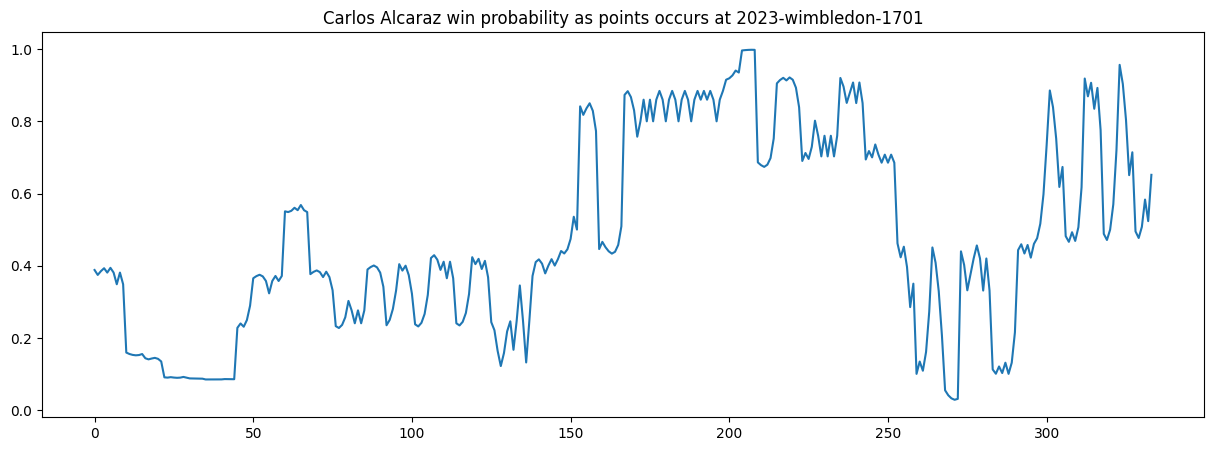

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(data_1701.index, data_1701['win_pct_bfr'].astype('float'))
plt.title('Carlos Alcaraz win probability as points occurs at 2023-wimbledon-1701')

Text(0.5, 1.0, 'Carlos Alcaraz win probability as points occurs at 2023-wimbledon-1701')

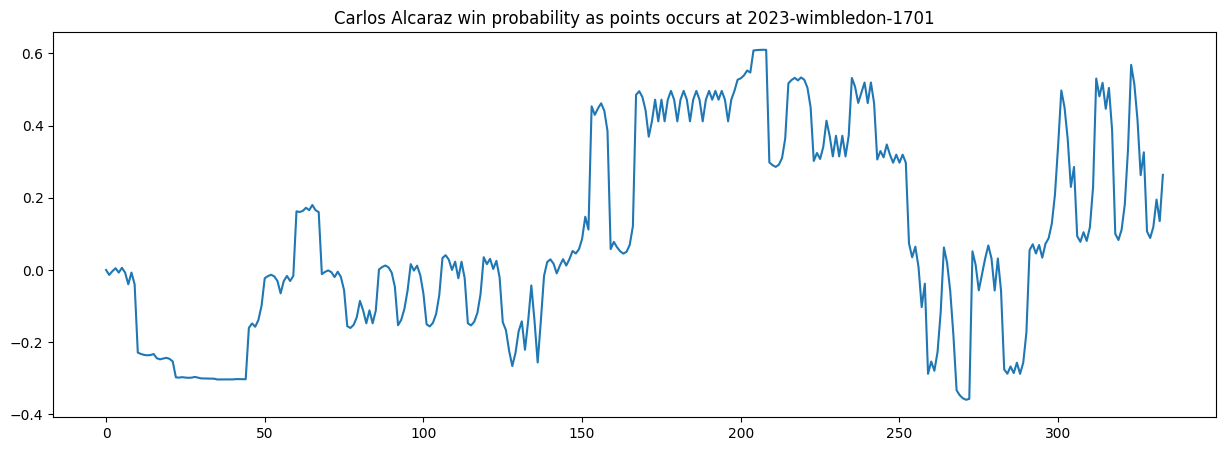

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(data_1701.index, data_1701['p1_perform'].astype('float'))
plt.title('Carlos Alcaraz win probability as points occurs at 2023-wimbledon-1701')

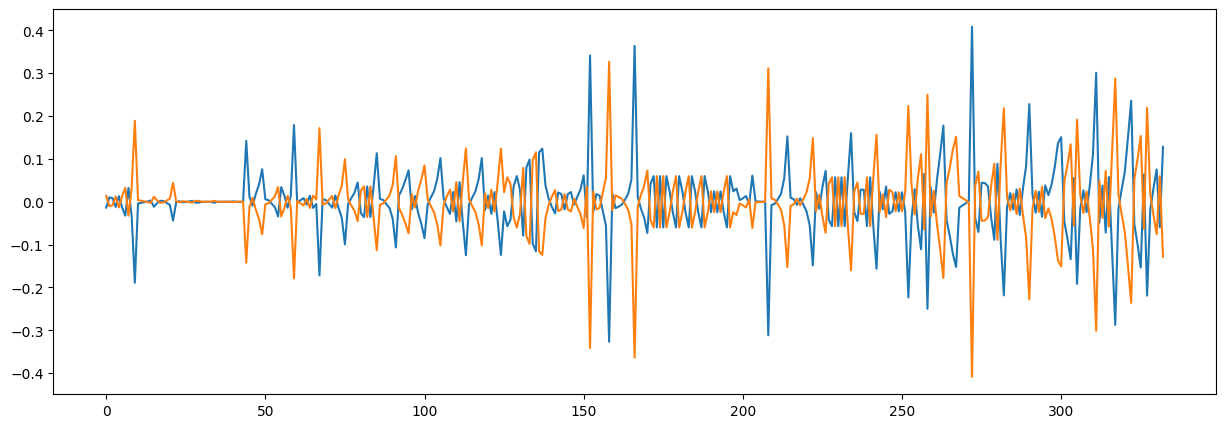

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(data_1701.index, data_1701['p1_performance'].astype('float'))
plt.plot(data_1701.index, data_1701['p2_performance'].astype('float'))

Text(0.5, 1.0, 'Win Probability as points occurs')

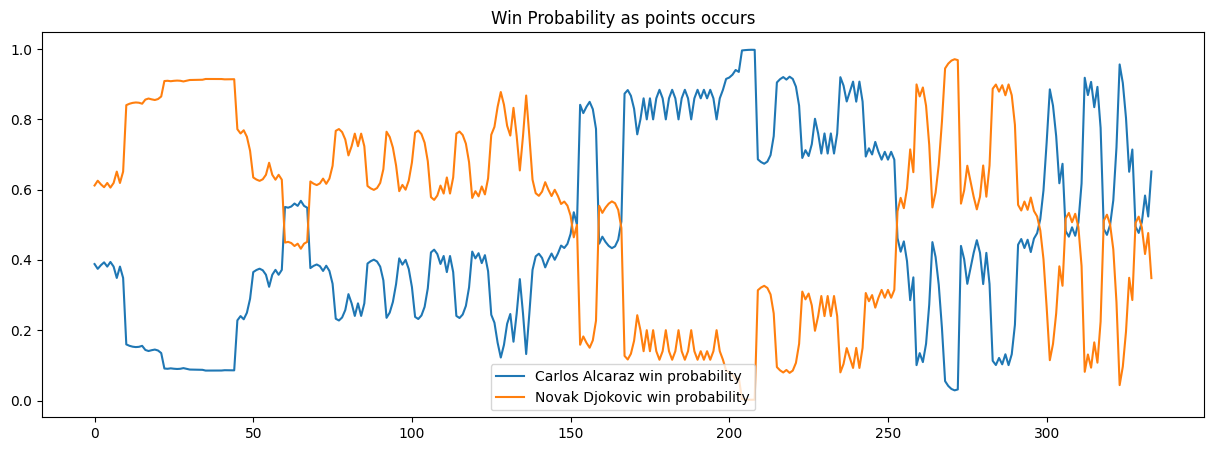

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(data_1701.index, data_1701['win_pct_bfr'].astype('float'))
plt.plot(data_1701.index, data_1701['opp_pct_bfr'].astype('float'))
plt.legend(['Carlos Alcaraz win probability','Novak Djokovic win probability'])
plt.title('Win Probability as points occurs')

In [ ]:
data_1701['p1_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1701)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1701.loc[i,['p1_performance']].values[0] > 0 and data_1701.loc[i+1,['p1_performance']].values[0] > 0 and data_1701.loc[i+2,['p1_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1701.loc[i,['p1_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1701.loc[i,['p1_performance']].values[0] < 0:
    data_1701.loc[i,['p1_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1701.loc[i,['p1_momentum']] = 1
    current_momentum += 1
  else:
    data_1701.loc[i,['p1_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

19 13


In [ ]:
data_1701['p2_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1701)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1701.loc[i,['p2_performance']].values[0] > 0 and data_1701.loc[i+1,['p2_performance']].values[0] > 0 and data_1701.loc[i+2,['p2_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1701.loc[i,['p2_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1701.loc[i,['p2_performance']].values[0] < 0:
    data_1701.loc[i,['p2_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1701.loc[i,['p2_momentum']] = 1
    current_momentum += 1
  else:
    data_1701.loc[i,['p2_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

22 10


In [ ]:
data_1701['p1_momentum_start'] = ''
tick = False
for i in range(0,len(data_1701)-3):
  if data_1701.loc[i,['p1_performance']].values[0] > 0 and data_1701.loc[i+1,['p1_performance']].values[0] > 0 and data_1701.loc[i+2,['p1_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1701.loc[i,['p1_momentum_start']] = 1
  elif data_1701.loc[i,['p1_performance']].values[0] < 0:
    data_1701.loc[i,['p1_momentum_start']] = 0
    tick = False
  else:
    data_1701.loc[i,['p1_momentum_start']] = 0

In [ ]:
data_1701['p2_momentum_start'] = ''
tick = False
for i in range(0,len(data_1701)-3):
  if data_1701.loc[i,['p2_performance']].values[0] > 0 and data_1701.loc[i+1,['p2_performance']].values[0] > 0 and data_1701.loc[i+2,['p2_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1701.loc[i,['p2_momentum_start']] = 1
  elif data_1701.loc[i,['p2_performance']].values[0] < 0:
    data_1701.loc[i,['p2_momentum_start']] = 0
    tick = False
  else:
    data_1701.loc[i,['p2_momentum_start']] = 0

In [ ]:
data_1701['momentum_start'] = data_1701['p1_momentum_start'] + data_1701['p2_momentum_start']

In [ ]:
data_1701['momentum_start'].value_counts()

0    290
1     41
       3
Name: momentum_start, dtype: int64

In [ ]:
fig = px.scatter(data_1701, x = data_1701.index, y = 'win_pct_after',color = 'p1_momentum')
fig.show()

In [ ]:
fig = px.scatter(data_1701, x = data_1701.index, y = 'opp_pct_after',color = 'p2_momentum')
fig.show()

## 2023-wimbledon-1403

In [ ]:
data_1403 = data[data.loc[:,'match_id'] == '2023-wimbledon-1403']
data_1403 = data_1403.reset_index(drop = True)
data_1403

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,p2_games,p1_score,p2_score,server,serve_no,point_victor,p1_points_won,p2_points_won,game_victor,set_victor,p1_ace,p2_ace,p1_winner,p2_winner,winner_shot_type,p1_double_fault,p2_double_fault,p1_unf_err,p2_unf_err,p1_net_pt,p2_net_pt,p1_net_pt_won,p2_net_pt_won,p1_break_pt,p2_break_pt,p1_break_pt_won,p2_break_pt_won,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji
0,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:00:00,1,1,1,0,0,0,0,0,0,2,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15.999,18.557,3,112.0,W,CTL,ND,0.66,0.4,0.64,0.35,0.781,0.711
1,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:00:26,1,1,2,0,0,0,0,0,1,2,2,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,26.087,22.571,6,100.0,B,NCTL,ND,0.66,0.4,0.64,0.35,0.781,0.711
2,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:01:10,1,1,3,0,0,0,0,1,1,2,2,2,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4.538,5.213,1,109.0,B,CTL,D,0.66,0.4,0.64,0.35,0.781,0.711
3,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:01:42,1,1,4,0,0,0,0,1,2,2,1,1,2,2,0,0,0,0,1,0,B,0,0,0,0,0,1,0,0,0,0,0,0,0,0,6.779,7.981,2,124.0,W,CTL,ND,0.66,0.4,0.64,0.35,0.781,0.711
4,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:02:05,1,1,5,0,0,0,0,2,2,2,2,1,3,2,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1.038,0.961,0,NaN,W,CTL,NaN,0.66,0.4,0.64,0.35,0.781,0.711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:27:51,2,8,118,1,0,5,2,1,0,1,2,1,68,50,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25.521,27.601,9,86.0,B,NCTL,ND,0.66,0.4,0.64,0.35,0.781,0.711
118,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:28:33,2,8,119,1,0,5,2,2,0,1,1,1,69,50,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.884,1.102,1,125.0,C,CTL,NaN,0.66,0.4,0.64,0.35,0.781,0.711
119,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:28:49,2,8,120,1,0,5,2,3,0,1,2,2,69,51,0,0,0,0,0,1,F,0,0,0,0,1,0,0,0,0,0,0,0,0,0,16.262,14.258,4,112.0,C,NCTL,ND,0.66,0.4,0.64,0.35,0.781,0.711
120,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:29:25,2,8,121,1,0,5,2,3,1,1,2,2,69,52,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,6.513,7.821,2,102.0,B,NCTL,D,0.66,0.4,0.64,0.35,0.781,0.711


In [ ]:
data_1403['win_pct_bfr'] = ''
for i in range(0, len(data_1403)):
  match = 0
  set = 0
  data_1403.loc[i,['win_pct_bfr']] = Pm(int(data_1403.loc[i, ['p1_sets']].values[0]), int(data_1403.loc[i, ['p2_sets']].values[0]), int(data_1403.loc[i, ['p1_games']].values[0]), int(data_1403.loc[i, ['p2_games']].values[0]), int(data_1403.loc[i, ['p1_score']].values[0]), int(data_1403.loc[i, ['p2_score']].values[0]), data_1403.loc[i, ['fij']].values[0], data_1403.loc[i, ['fji']].values[0])
  print(i+1)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122


In [ ]:
# data_1403.to_csv('/content/drive/MyDrive/MCM 2024/data_1403.csv')

In [ ]:
data_1403 = pd.read_csv('/content/drive/MyDrive/MCM 2024/data_1403.csv', index_col = 0)
data_1403

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji,win_pct_bfr
0,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:00:00,1,1,1,0,0,0,...,W,CTL,ND,0.66,0.4,0.64,0.35,0.781,0.711,0.832060
1,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:00:26,1,1,2,0,0,0,...,B,NCTL,ND,0.66,0.4,0.64,0.35,0.781,0.711,0.824416
2,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:01:10,1,1,3,0,0,0,...,B,CTL,D,0.66,0.4,0.64,0.35,0.781,0.711,0.829860
3,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:01:42,1,1,4,0,0,0,...,W,CTL,ND,0.66,0.4,0.64,0.35,0.781,0.711,0.816452
4,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:02:05,1,1,5,0,0,0,...,W,CTL,NaN,0.66,0.4,0.64,0.35,0.781,0.711,0.826644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:27:51,2,8,118,1,0,5,...,B,NCTL,ND,0.66,0.4,0.64,0.35,0.781,0.711,0.999140
118,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:28:33,2,8,119,1,0,5,...,C,CTL,NaN,0.66,0.4,0.64,0.35,0.781,0.711,0.999149
119,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:28:49,2,8,120,1,0,5,...,C,NCTL,ND,0.66,0.4,0.64,0.35,0.781,0.711,0.999153
120,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:29:25,2,8,121,1,0,5,...,B,NCTL,D,0.66,0.4,0.64,0.35,0.781,0.711,0.999150


In [ ]:
data_1403['win_pct_after'] = data_1403['win_pct_bfr'].shift(-1)
data_1403['p1_performance'] = data_1403['win_pct_after'] - data_1403['win_pct_bfr']
data_1403['p1_perform'] = data_1403['win_pct_bfr'] - data_1403.loc[0, 'win_pct_bfr']
data_1403['opp_pct_bfr'] = 1-data_1403['win_pct_bfr']
data_1403['opp_pct_after'] = data_1403['opp_pct_bfr'].shift(-1)
data_1403['p2_performance'] = data_1403['opp_pct_after'] - data_1403['opp_pct_bfr']
data_1403['p2_perform'] = data_1403['opp_pct_bfr'] - data_1403.loc[0, 'opp_pct_bfr']

data_1403

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,fij,fji,win_pct_bfr,win_pct_after,p1_performance,p1_perform,opp_pct_bfr,opp_pct_after,p2_performance,p2_perform
0,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:00:00,1,1,1,0,0,0,...,0.781,0.711,0.832060,0.824416,-0.007644,0.000000,0.167940,0.175584,0.007644,0.000000
1,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:00:26,1,1,2,0,0,0,...,0.781,0.711,0.824416,0.829860,0.005444,-0.007644,0.175584,0.170140,-0.005444,0.007644
2,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:01:10,1,1,3,0,0,0,...,0.781,0.711,0.829860,0.816452,-0.013408,-0.002200,0.170140,0.183548,0.013408,0.002200
3,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:01:42,1,1,4,0,0,0,...,0.781,0.711,0.816452,0.826644,0.010192,-0.015608,0.183548,0.173356,-0.010192,0.015608
4,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,00:02:05,1,1,5,0,0,0,...,0.781,0.711,0.826644,0.833971,0.007327,-0.005416,0.173356,0.166029,-0.007327,0.005416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:27:51,2,8,118,1,0,5,...,0.781,0.711,0.999140,0.999149,0.000009,0.167080,0.000860,0.000851,-0.000009,-0.167080
118,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:28:33,2,8,119,1,0,5,...,0.781,0.711,0.999149,0.999153,0.000004,0.167089,0.000851,0.000847,-0.000004,-0.167089
119,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:28:49,2,8,120,1,0,5,...,0.781,0.711,0.999153,0.999150,-0.000003,0.167093,0.000847,0.000850,0.000003,-0.167093
120,2023-wimbledon-1403,Daniil Medvedev,Jiri Lehecka,01:29:25,2,8,121,1,0,5,...,0.781,0.711,0.999150,0.999138,-0.000012,0.167090,0.000850,0.000862,0.000012,-0.167090


Text(0.5, 1.0, 'Daniil Medvedec win probability as points occurs at 2023-wimbledon-1403')

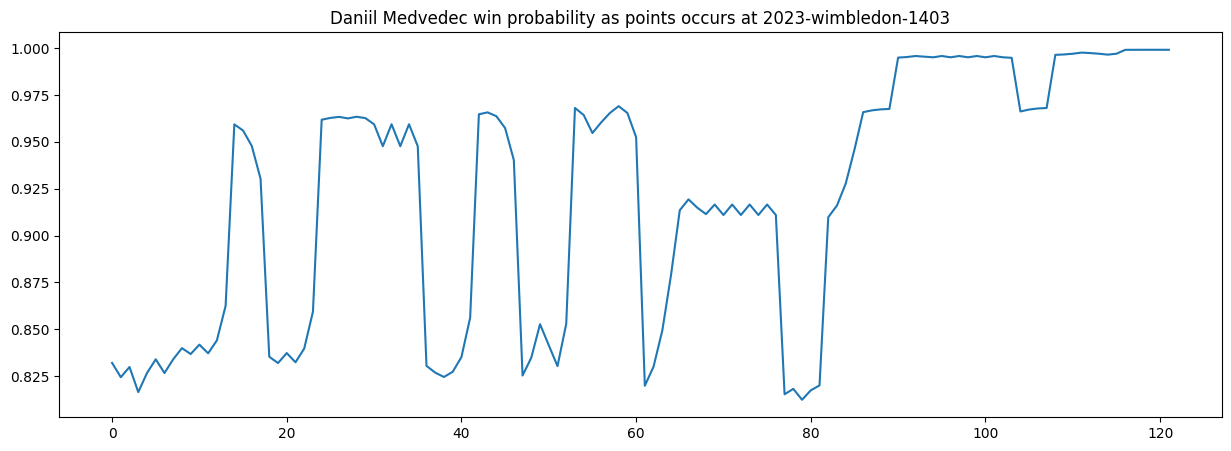

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(data_1403.index, data_1403['win_pct_bfr'].astype('float'))
plt.title('Daniil Medvedec win probability as points occurs at 2023-wimbledon-1403')

In [ ]:
data_1403['p1_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1403)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1403.loc[i,['p1_performance']].values[0] > 0 and data_1403.loc[i+1,['p1_performance']].values[0] > 0 and data_1403.loc[i+2,['p1_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1403.loc[i,['p1_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1403.loc[i,['p1_performance']].values[0] < 0:
    data_1403.loc[i,['p1_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1403.loc[i,['p1_momentum']] = 1
    current_momentum += 1
  else:
    data_1403.loc[i,['p1_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

8 6


In [ ]:
data_1403['p2_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1403)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1403.loc[i,['p2_performance']].values[0] > 0 and data_1403.loc[i+1,['p2_performance']].values[0] > 0 and data_1403.loc[i+2,['p2_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1403.loc[i,['p2_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1403.loc[i,['p2_performance']].values[0] < 0:
    data_1403.loc[i,['p2_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1403.loc[i,['p2_momentum']] = 1
    current_momentum += 1
  else:
    data_1403.loc[i,['p2_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

7 3


In [ ]:
data_1403['p1_momentum_start'] = ''
tick = False
for i in range(0,len(data_1403)-3):
  if data_1403.loc[i,['p1_performance']].values[0] > 0 and data_1403.loc[i+1,['p1_performance']].values[0] > 0 and data_1403.loc[i+2,['p1_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1403.loc[i,['p1_momentum_start']] = 1
  elif data_1403.loc[i,['p1_performance']].values[0] < 0:
    data_1403.loc[i,['p1_momentum_start']] = 0
    tick = False
  else:
    data_1403.loc[i,['p1_momentum_start']] = 0

In [ ]:
data_1403['p2_momentum_start'] = ''
tick = False
for i in range(0,len(data_1403)-3):
  if data_1403.loc[i,['p2_performance']].values[0] > 0 and data_1403.loc[i+1,['p2_performance']].values[0] > 0 and data_1403.loc[i+2,['p2_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1403.loc[i,['p2_momentum_start']] = 1
  elif data_1403.loc[i,['p2_performance']].values[0] < 0:
    data_1403.loc[i,['p2_momentum_start']] = 0
    tick = False
  else:
    data_1403.loc[i,['p2_momentum_start']] = 0

In [ ]:
data_1403['momentum_start'] = data_1403['p1_momentum_start'] + data_1403['p2_momentum_start']

In [ ]:
data_1403['momentum_start'].value_counts()

0    104
1     15
       3
Name: momentum_start, dtype: int64

In [ ]:
fig = px.scatter(data_1403, x = data_1403.index, y = 'win_pct_after',color = 'p1_momentum')
fig.show()

## 2023-wimbledon-1303

In [ ]:
data_1303 = data[data.loc[:,'match_id'] == '2023-wimbledon-1303']
data_1303 = data_1303.reset_index(drop = True)
data_1303

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,p2_games,p1_score,p2_score,server,serve_no,point_victor,p1_points_won,p2_points_won,game_victor,set_victor,p1_ace,p2_ace,p1_winner,p2_winner,winner_shot_type,p1_double_fault,p2_double_fault,p1_unf_err,p2_unf_err,p1_net_pt,p2_net_pt,p1_net_pt_won,p2_net_pt_won,p1_break_pt,p2_break_pt,p1_break_pt_won,p2_break_pt_won,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji
0,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:00:00,1,1,1,0,0,0,0,0,0,2,2,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8.929,6.360,2,99.0,BC,NCTL,ND,0.65,0.35,0.66,0.37,0.751,0.781
1,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:00:33,1,1,2,0,0,0,0,1,0,2,2,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.196,5.892,1,103.0,B,NCTL,D,0.65,0.35,0.66,0.37,0.751,0.781
2,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:01:04,1,1,3,0,0,0,0,1,1,2,1,2,1,2,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,28.364,27.314,7,115.0,BW,NCTL,ND,0.65,0.35,0.66,0.37,0.751,0.781
3,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:01:36,1,1,4,0,0,0,0,1,2,2,1,2,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.553,4.084,1,126.0,C,NCTL,ND,0.65,0.35,0.66,0.37,0.751,0.781
4,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:01:56,1,1,5,0,0,0,0,1,3,2,1,2,1,4,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.364,0.694,1,121.0,W,CTL,NaN,0.65,0.35,0.66,0.37,0.751,0.781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:35:02,3,8,130,0,2,2,5,0,0,2,2,2,50,80,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,19.826,18.539,5,103.0,BC,CTL,ND,0.65,0.35,0.66,0.37,0.751,0.781
130,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:35:40,3,8,131,0,2,2,5,0,1,2,2,2,50,81,0,0,0,0,0,1,B,0,0,0,0,0,1,0,1,0,0,0,0,0,0,45.494,40.420,9,91.0,B,CTL,ND,0.65,0.35,0.66,0.37,0.751,0.781
131,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:36:39,3,8,132,0,2,2,5,0,2,2,1,2,50,82,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,27.928,27.193,7,132.0,C,NCTL,D,0.65,0.35,0.66,0.37,0.751,0.781
132,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:37:17,3,8,133,0,2,2,5,0,3,2,2,1,51,82,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5.251,3.098,2,93.0,BW,NCTL,ND,0.65,0.35,0.66,0.37,0.751,0.781


In [ ]:
data_1303['win_pct_bfr'] = ''
for i in range(0, len(data_1303)):
  match = 0
  set = 0
  data_1303.loc[i,['win_pct_bfr']] = Pm(int(data_1303.loc[i, ['p1_sets']].values[0]), int(data_1303.loc[i, ['p2_sets']].values[0]), int(data_1303.loc[i, ['p1_games']].values[0]), int(data_1303.loc[i, ['p2_games']].values[0]), int(data_1303.loc[i, ['p1_score']].values[0]), int(data_1303.loc[i, ['p2_score']].values[0]), data_1303.loc[i, ['fij']].values[0], data_1303.loc[i, ['fji']].values[0])
  print(i+1)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134


In [ ]:
# data_1303.to_csv('/content/drive/MyDrive/MCM 2024/data_1303.csv')

In [ ]:
data_1303 = pd.read_csv('/content/drive/MyDrive/MCM 2024/data_1303.csv', index_col = 0)
data_1303

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji,win_pct_bfr
0,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:00:00,1,1,1,0,0,0,...,BC,NCTL,ND,0.65,0.35,0.66,0.37,0.751,0.781,3.436113e-01
1,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:00:33,1,1,2,0,0,0,...,B,NCTL,D,0.65,0.35,0.66,0.37,0.751,0.781,3.470839e-01
2,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:01:04,1,1,3,0,0,0,...,BW,NCTL,ND,0.65,0.35,0.66,0.37,0.751,0.781,3.408109e-01
3,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:01:36,1,1,4,0,0,0,...,C,NCTL,ND,0.65,0.35,0.66,0.37,0.751,0.781,3.240083e-01
4,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:01:56,1,1,5,0,0,0,...,W,CTL,NaN,0.65,0.35,0.66,0.37,0.751,0.781,2.846222e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:35:02,3,8,130,0,2,2,...,BC,CTL,ND,0.65,0.35,0.66,0.37,0.751,0.781,6.436010e-08
130,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:35:40,3,8,131,0,2,2,...,B,CTL,ND,0.65,0.35,0.66,0.37,0.751,0.781,2.957030e-08
131,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:36:39,3,8,132,0,2,2,...,C,NCTL,D,0.65,0.35,0.66,0.37,0.751,0.781,9.801139e-09
132,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:37:17,3,8,133,0,2,2,...,BW,NCTL,ND,0.65,0.35,0.66,0.37,0.751,0.781,1.599348e-09


In [ ]:
data_1303['win_pct_after'] = data_1303['win_pct_bfr'].shift(-1)
data_1303['p1_performance'] = data_1303['win_pct_after'] - data_1303['win_pct_bfr']
data_1303['p1_perform'] = data_1303['win_pct_bfr'] - data_1303.loc[0, 'win_pct_bfr']
data_1303['opp_pct_bfr'] = 1-data_1303['win_pct_bfr']
data_1303['opp_pct_after'] = data_1303['opp_pct_bfr'].shift(-1)
data_1303['p2_performance'] = data_1303['opp_pct_after'] - data_1303['opp_pct_bfr']
data_1303['p2_perform'] = data_1303['opp_pct_bfr'] - data_1303.loc[0, 'opp_pct_bfr']

data_1303

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,fij,fji,win_pct_bfr,win_pct_after,p1_performance,p1_perform,opp_pct_bfr,opp_pct_after,p2_performance,p2_perform
0,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:00:00,1,1,1,0,0,0,...,0.751,0.781,3.436113e-01,3.470839e-01,3.472603e-03,0.000000,0.656389,0.652916,-3.472603e-03,0.000000
1,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:00:33,1,1,2,0,0,0,...,0.751,0.781,3.470839e-01,3.408109e-01,-6.272999e-03,0.003473,0.652916,0.659189,6.272999e-03,-0.003473
2,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:01:04,1,1,3,0,0,0,...,0.751,0.781,3.408109e-01,3.240083e-01,-1.680265e-02,-0.002800,0.659189,0.675992,1.680265e-02,0.002800
3,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:01:36,1,1,4,0,0,0,...,0.751,0.781,3.240083e-01,2.846222e-01,-3.938612e-02,-0.019603,0.675992,0.715378,3.938612e-02,0.019603
4,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,00:01:56,1,1,5,0,0,0,...,0.751,0.781,2.846222e-01,1.058825e-01,-1.787397e-01,-0.058989,0.715378,0.894117,1.787397e-01,0.058989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:35:02,3,8,130,0,2,2,...,0.751,0.781,6.436010e-08,2.957030e-08,-3.478980e-08,-0.343611,1.000000,1.000000,3.478980e-08,0.343611
130,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:35:40,3,8,131,0,2,2,...,0.751,0.781,2.957030e-08,9.801139e-09,-1.976916e-08,-0.343611,1.000000,1.000000,1.976916e-08,0.343611
131,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:36:39,3,8,132,0,2,2,...,0.751,0.781,9.801139e-09,1.599348e-09,-8.201792e-09,-0.343611,1.000000,1.000000,8.201792e-09,0.343611
132,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,25:37:17,3,8,133,0,2,2,...,0.751,0.781,1.599348e-09,7.302958e-09,5.703610e-09,-0.343611,1.000000,1.000000,-5.703610e-09,0.343611


Text(0.5, 1.0, 'Frances Tiafoe win probability as points occurs at 2023-wimbledon-1303')

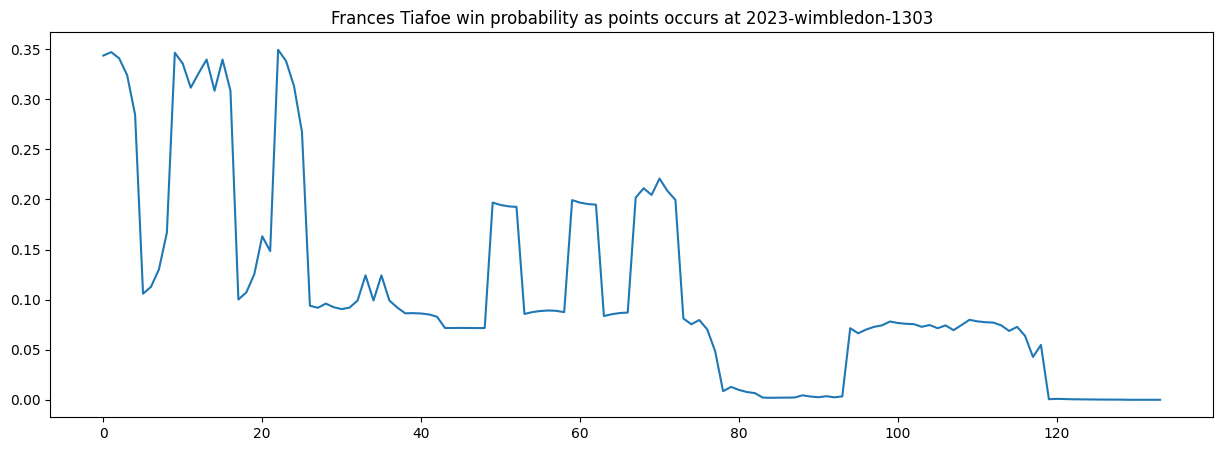

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(data_1303.index, data_1303['win_pct_bfr'].astype('float'))
plt.title('Frances Tiafoe win probability as points occurs at 2023-wimbledon-1303')

In [ ]:
data_1303['p1_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1303)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1303.loc[i,['p1_performance']].values[0] > 0 and data_1303.loc[i+1,['p1_performance']].values[0] > 0 and data_1303.loc[i+2,['p1_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1303.loc[i,['p1_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1303.loc[i,['p1_performance']].values[0] < 0:
    data_1303.loc[i,['p1_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1303.loc[i,['p1_momentum']] = 1
    current_momentum += 1
  else:
    data_1303.loc[i,['p1_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

7 4


In [ ]:
data_1303['p2_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1303)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1303.loc[i,['p2_performance']].values[0] > 0 and data_1303.loc[i+1,['p2_performance']].values[0] > 0 and data_1303.loc[i+2,['p2_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1303.loc[i,['p2_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1303.loc[i,['p2_performance']].values[0] < 0:
    data_1303.loc[i,['p2_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1303.loc[i,['p2_momentum']] = 1
    current_momentum += 1
  else:
    data_1303.loc[i,['p2_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

13 10


In [ ]:
data_1303['p1_momentum_start'] = ''
tick = False
for i in range(0,len(data_1303)-3):
  if data_1303.loc[i,['p1_performance']].values[0] > 0 and data_1303.loc[i+1,['p1_performance']].values[0] > 0 and data_1303.loc[i+2,['p1_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1303.loc[i,['p1_momentum_start']] = 1
  elif data_1303.loc[i,['p1_performance']].values[0] < 0:
    data_1303.loc[i,['p1_momentum_start']] = 0
    tick = False
  else:
    data_1303.loc[i,['p1_momentum_start']] = 0

In [ ]:
data_1303['p2_momentum_start'] = ''
tick = False
for i in range(0,len(data_1303)-3):
  if data_1303.loc[i,['p2_performance']].values[0] > 0 and data_1303.loc[i+1,['p2_performance']].values[0] > 0 and data_1303.loc[i+2,['p2_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1303.loc[i,['p2_momentum_start']] = 1
  elif data_1303.loc[i,['p2_performance']].values[0] < 0:
    data_1303.loc[i,['p2_momentum_start']] = 0
    tick = False
  else:
    data_1303.loc[i,['p2_momentum_start']] = 0

In [ ]:
data_1303['momentum_start'] = data_1303['p1_momentum_start'] + data_1303['p2_momentum_start']

In [ ]:
fig = px.scatter(data_1303, x = data_1303.index, y = 'win_pct_after',color = 'p1_momentum')
fig.show()

In [ ]:
fig = px.scatter(data_1303, x = data_1303.index, y = 'opp_pct_after',color = 'p2_momentum')
fig.show()

## 2023-wimbledon-1306

In [ ]:
data_1306 = data[data.loc[:,'match_id'] == '2023-wimbledon-1306']
data_1306 = data_1306.reset_index(drop = True)
data_1306

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,speed_mph,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji
0,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:00:00,1,1,1,0,0,0,...,102.0,W,CTL,NaN,0.64,0.35,0.64,0.38,0.731,0.761
1,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:00:35,1,1,2,0,0,0,...,125.0,W,NCTL,ND,0.64,0.35,0.64,0.38,0.731,0.761
2,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:00:58,1,1,3,0,0,0,...,101.0,B,NCTL,D,0.64,0.35,0.64,0.38,0.731,0.761
3,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:01:39,1,1,4,0,0,0,...,121.0,C,CTL,ND,0.64,0.35,0.64,0.38,0.731,0.761
4,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:02:03,1,1,5,0,0,0,...,126.0,C,CTL,NaN,0.64,0.35,0.64,0.38,0.731,0.761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:17:10,5,8,328,2,2,5,...,111.0,C,NCTL,ND,0.64,0.35,0.64,0.38,0.731,0.761
328,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:17:31,5,8,329,2,2,5,...,93.0,BC,NCTL,ND,0.64,0.35,0.64,0.38,0.731,0.761
329,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:18:09,5,8,330,2,2,5,...,116.0,C,NCTL,ND,0.64,0.35,0.64,0.38,0.731,0.761
330,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:19:08,5,8,331,2,2,5,...,92.0,BC,NCTL,D,0.64,0.35,0.64,0.38,0.731,0.761


In [ ]:
data_1306['win_pct_bfr'] = ''
for i in range(0, len(data_1306)):
  match = 0
  set = 0
  data_1306.loc[i,['win_pct_bfr']] = Pm(int(data_1306.loc[i, ['p1_sets']].values[0]), int(data_1306.loc[i, ['p2_sets']].values[0]), int(data_1306.loc[i, ['p1_games']].values[0]), int(data_1306.loc[i, ['p2_games']].values[0]), int(data_1306.loc[i, ['p1_score']].values[0]), int(data_1306.loc[i, ['p2_score']].values[0]), data_1306.loc[i, ['fij']].values[0], data_1306.loc[i, ['fji']].values[0])
  print(i+1)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [ ]:
# data_1306.to_csv('/content/drive/MyDrive/MCM 2024/data_1306.csv')

In [ ]:
data_1306 = pd.read_csv('/content/drive/MyDrive/MCM 2024/data_1306.csv', index_col=0)
data_1306

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji,win_pct_bfr
0,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:00:00,1,1,1,0,0,0,...,W,CTL,NaN,0.64,0.35,0.64,0.38,0.731,0.761,0.339968
1,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:00:35,1,1,2,0,0,0,...,W,NCTL,ND,0.64,0.35,0.64,0.38,0.731,0.761,0.328250
2,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:00:58,1,1,3,0,0,0,...,B,NCTL,D,0.64,0.35,0.64,0.38,0.731,0.761,0.304455
3,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:01:39,1,1,4,0,0,0,...,C,CTL,ND,0.64,0.35,0.64,0.38,0.731,0.761,0.319127
4,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:02:03,1,1,5,0,0,0,...,C,CTL,NaN,0.64,0.35,0.64,0.38,0.731,0.761,0.280778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:17:10,5,8,328,2,2,5,...,C,NCTL,ND,0.64,0.35,0.64,0.38,0.731,0.761,0.968247
328,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:17:31,5,8,329,2,2,5,...,BC,NCTL,ND,0.64,0.35,0.64,0.38,0.731,0.761,0.966374
329,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:18:09,5,8,330,2,2,5,...,C,NCTL,ND,0.64,0.35,0.64,0.38,0.731,0.761,0.970632
330,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:19:08,5,8,331,2,2,5,...,BC,NCTL,D,0.64,0.35,0.64,0.38,0.731,0.761,0.981090


In [ ]:
data_1306['win_pct_after'] = data_1306['win_pct_bfr'].shift(-1)
data_1306['p1_performance'] = data_1306['win_pct_after'] - data_1306['win_pct_bfr']
data_1306['p1_perform'] = data_1306['win_pct_bfr'] - data_1306.loc[0, 'win_pct_bfr']
data_1306['opp_pct_bfr'] = 1-data_1306['win_pct_bfr']
data_1306['opp_pct_after'] = data_1306['opp_pct_bfr'].shift(-1)
data_1306['p2_performance'] = data_1306['opp_pct_after'] - data_1306['opp_pct_bfr']
data_1306['p2_perform'] = data_1306['opp_pct_bfr'] - data_1306.loc[0, 'opp_pct_bfr']

data_1306

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,fij,fji,win_pct_bfr,win_pct_after,p1_performance,p1_perform,opp_pct_bfr,opp_pct_after,p2_performance,p2_perform
0,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:00:00,1,1,1,0,0,0,...,0.731,0.761,0.339968,0.328250,-0.011719,0.000000,0.660032,0.671750,0.011719,0.000000
1,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:00:35,1,1,2,0,0,0,...,0.731,0.761,0.328250,0.304455,-0.023794,-0.011719,0.671750,0.695545,0.023794,0.011719
2,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:00:58,1,1,3,0,0,0,...,0.731,0.761,0.304455,0.319127,0.014672,-0.035513,0.695545,0.680873,-0.014672,0.035513
3,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:01:39,1,1,4,0,0,0,...,0.731,0.761,0.319127,0.280778,-0.038349,-0.020841,0.680873,0.719222,0.038349,0.020841
4,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,00:02:03,1,1,5,0,0,0,...,0.731,0.761,0.280778,0.115708,-0.165071,-0.059190,0.719222,0.884292,0.165071,0.059190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:17:10,5,8,328,2,2,5,...,0.731,0.761,0.968247,0.966374,-0.001873,0.628279,0.031753,0.033626,0.001873,-0.628279
328,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:17:31,5,8,329,2,2,5,...,0.731,0.761,0.966374,0.970632,0.004258,0.626405,0.033626,0.029368,-0.004258,-0.626405
329,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:18:09,5,8,330,2,2,5,...,0.731,0.761,0.970632,0.981090,0.010458,0.630664,0.029368,0.018910,-0.010458,-0.630664
330,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,06:19:08,5,8,331,2,2,5,...,0.731,0.761,0.981090,0.975151,-0.005939,0.641122,0.018910,0.024849,0.005939,-0.641122


Text(0.5, 1.0, 'Daniil Medvedec win probability as points occurs at 2023-wimbledon-1403')

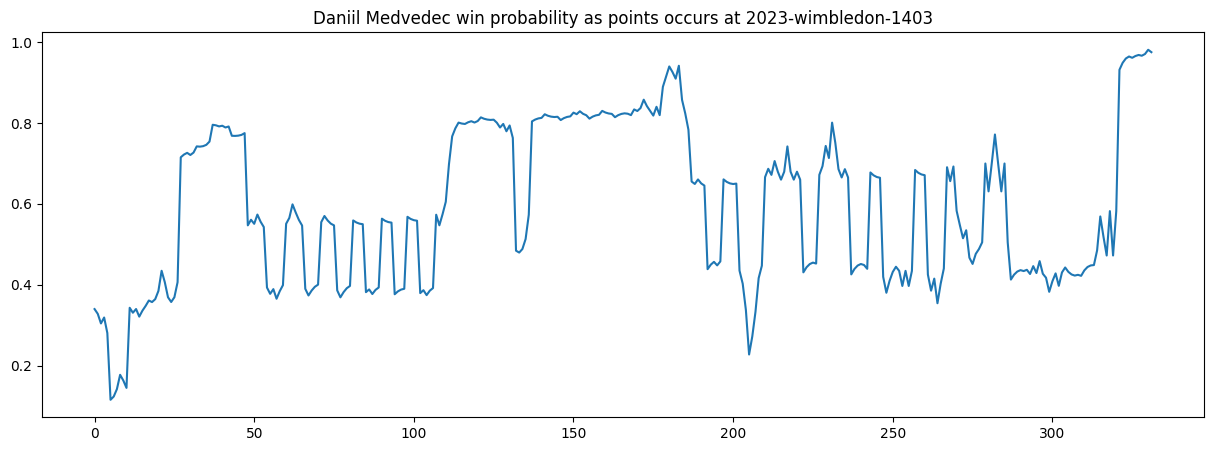

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(data_1306.index, data_1306['win_pct_bfr'].astype('float'))
plt.title('Daniil Medvedec win probability as points occurs at 2023-wimbledon-1403')

In [ ]:
data_1306['p1_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1306)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1306.loc[i,['p1_performance']].values[0] > 0 and data_1306.loc[i+1,['p1_performance']].values[0] > 0 and data_1306.loc[i+2,['p1_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1306.loc[i,['p1_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1306.loc[i,['p1_performance']].values[0] < 0:
    data_1306.loc[i,['p1_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1306.loc[i,['p1_momentum']] = 1
    current_momentum += 1
  else:
    data_1306.loc[i,['p1_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

28 14


In [ ]:
data_1306['p2_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1306)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1306.loc[i,['p2_performance']].values[0] > 0 and data_1306.loc[i+1,['p2_performance']].values[0] > 0 and data_1306.loc[i+2,['p2_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1306.loc[i,['p2_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1306.loc[i,['p2_performance']].values[0] < 0:
    data_1306.loc[i,['p2_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1306.loc[i,['p2_momentum']] = 1
    current_momentum += 1
  else:
    data_1306.loc[i,['p2_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

23 11


In [ ]:
data_1306['p1_momentum_start'] = ''
tick = False
for i in range(0,len(data_1306)-3):
  if data_1306.loc[i,['p1_performance']].values[0] > 0 and data_1306.loc[i+1,['p1_performance']].values[0] > 0 and data_1306.loc[i+2,['p1_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1306.loc[i,['p1_momentum_start']] = 1
  elif data_1306.loc[i,['p1_performance']].values[0] < 0:
    data_1306.loc[i,['p1_momentum_start']] = 0
    tick = False
  else:
    data_1306.loc[i,['p1_momentum_start']] = 0

In [ ]:
data_1306['p2_momentum_start'] = ''
tick = False
for i in range(0,len(data_1306)-3):
  if data_1306.loc[i,['p2_performance']].values[0] > 0 and data_1306.loc[i+1,['p2_performance']].values[0] > 0 and data_1306.loc[i+2,['p2_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1306.loc[i,['p2_momentum_start']] = 1
  elif data_1306.loc[i,['p2_performance']].values[0] < 0:
    data_1306.loc[i,['p2_momentum_start']] = 0
    tick = False
  else:
    data_1306.loc[i,['p2_momentum_start']] = 0

In [ ]:
data_1306['momentum_start'] = data_1306['p1_momentum_start'] + data_1306['p2_momentum_start']

In [ ]:
fig = px.scatter(data_1306, x = data_1306.index, y = 'win_pct_after',color = 'p1_momentum')
fig.show()

In [ ]:
fig = px.scatter(data_1306, x = data_1306.index, y = 'opp_pct_after',color = 'p2_momentum')
fig.show()

## 2023-wimbledon-1310

In [ ]:
data_1310 = data[data.loc[:,'match_id'] == '2023-wimbledon-1310']
data_1310 = data_1310.reset_index(drop = True)
data_1310

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,speed_mph,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji
0,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:00:00,1,1,1,0,0,0,...,NaN,BW,NCTL,D,0.61,0.37,0.59,0.39,0.691,0.691
1,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:00:35,1,1,2,0,0,0,...,NaN,B,CTL,NaN,0.61,0.37,0.59,0.39,0.691,0.691
2,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:01:00,1,1,3,0,0,0,...,NaN,BW,NCTL,ND,0.61,0.37,0.59,0.39,0.691,0.691
3,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:01:37,1,1,4,0,0,0,...,NaN,BW,NCTL,ND,0.61,0.37,0.59,0.39,0.691,0.691
4,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:02:05,1,1,5,0,0,0,...,NaN,C,NCTL,D,0.61,0.37,0.59,0.39,0.691,0.691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:16:54,5,7,314,2,2,5,...,NaN,BW,NCTL,D,0.61,0.37,0.59,0.39,0.691,0.691
314,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:17:41,5,7,315,2,2,5,...,NaN,C,NCTL,D,0.61,0.37,0.59,0.39,0.691,0.691
315,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:18:09,5,7,316,2,2,5,...,NaN,B,NCTL,D,0.61,0.37,0.59,0.39,0.691,0.691
316,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:18:43,5,7,317,2,2,5,...,NaN,B,NCTL,ND,0.61,0.37,0.59,0.39,0.691,0.691


In [ ]:
data_1310['win_pct_bfr'] = ''
for i in range(0, len(data_1310)):
  match = 0
  set = 0
  data_1310.loc[i,['win_pct_bfr']] = Pm(int(data_1310.loc[i, ['p1_sets']].values[0]), int(data_1310.loc[i, ['p2_sets']].values[0]), int(data_1310.loc[i, ['p1_games']].values[0]), int(data_1310.loc[i, ['p2_games']].values[0]), int(data_1310.loc[i, ['p1_score']].values[0]), int(data_1310.loc[i, ['p2_score']].values[0]), data_1310.loc[i, ['fij']].values[0], data_1310.loc[i, ['fji']].values[0])
  print(i+1)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [ ]:
# data_1310.to_csv('/content/drive/MyDrive/MCM 2024/data_1310.csv')

In [ ]:
data_1310 = pd.read_csv('/content/drive/MyDrive/MCM 2024/data_1310.csv', index_col = 0)
data_1310

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji,win_pct_bfr
0,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:00:00,1,1,1,0,0,0,...,BW,NCTL,D,0.61,0.37,0.59,0.39,0.691,0.691,0.500000
1,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:00:35,1,1,2,0,0,0,...,B,CTL,NaN,0.61,0.37,0.59,0.39,0.691,0.691,0.484472
2,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:01:00,1,1,3,0,0,0,...,BW,NCTL,ND,0.61,0.37,0.59,0.39,0.691,0.691,0.496566
3,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:01:37,1,1,4,0,0,0,...,BW,NCTL,ND,0.61,0.37,0.59,0.39,0.691,0.691,0.474748
4,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:02:05,1,1,5,0,0,0,...,C,NCTL,D,0.61,0.37,0.59,0.39,0.691,0.691,0.492546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:16:54,5,7,314,2,2,5,...,BW,NCTL,D,0.61,0.37,0.59,0.39,0.691,0.691,0.997477
314,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:17:41,5,7,315,2,2,5,...,C,NCTL,D,0.61,0.37,0.59,0.39,0.691,0.691,0.994053
315,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:18:09,5,7,316,2,2,5,...,B,NCTL,D,0.61,0.37,0.59,0.39,0.691,0.691,0.986852
316,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:18:43,5,7,317,2,2,5,...,B,NCTL,ND,0.61,0.37,0.59,0.39,0.691,0.691,0.992726


In [ ]:
data_1310['win_pct_after'] = data_1310['win_pct_bfr'].shift(-1)
data_1310['p1_performance'] = data_1310['win_pct_after'] - data_1310['win_pct_bfr']
data_1310['p1_perform'] = data_1310['win_pct_bfr'] - data_1310.loc[0, 'win_pct_bfr']
data_1310['opp_pct_bfr'] = 1-data_1310['win_pct_bfr']
data_1310['opp_pct_after'] = data_1310['opp_pct_bfr'].shift(-1)
data_1310['p2_performance'] = data_1310['opp_pct_after'] - data_1310['opp_pct_bfr']
data_1310['p2_perform'] = data_1310['opp_pct_bfr'] - data_1310.loc[0, 'opp_pct_bfr']

data_1310

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,fij,fji,win_pct_bfr,win_pct_after,p1_performance,p1_perform,opp_pct_bfr,opp_pct_after,p2_performance,p2_perform
0,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:00:00,1,1,1,0,0,0,...,0.691,0.691,0.500000,0.484472,-0.015528,0.000000,0.500000,0.515528,0.015528,0.000000
1,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:00:35,1,1,2,0,0,0,...,0.691,0.691,0.484472,0.496566,0.012095,-0.015528,0.515528,0.503434,-0.012095,0.015528
2,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:01:00,1,1,3,0,0,0,...,0.691,0.691,0.496566,0.474748,-0.021818,-0.003434,0.503434,0.525252,0.021818,0.003434
3,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:01:37,1,1,4,0,0,0,...,0.691,0.691,0.474748,0.492546,0.017797,-0.025252,0.525252,0.507454,-0.017797,0.025252
4,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,00:02:05,1,1,5,0,0,0,...,0.691,0.691,0.492546,0.507777,0.015231,-0.007454,0.507454,0.492223,-0.015231,0.007454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:16:54,5,7,314,2,2,5,...,0.691,0.691,0.997477,0.994053,-0.003425,0.497477,0.002523,0.005947,0.003425,-0.497477
314,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:17:41,5,7,315,2,2,5,...,0.691,0.691,0.994053,0.986852,-0.007200,0.494053,0.005947,0.013148,0.007200,-0.494053
315,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:18:09,5,7,316,2,2,5,...,0.691,0.691,0.986852,0.992726,0.005873,0.486852,0.013148,0.007274,-0.005873,-0.486852
316,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,04:18:43,5,7,317,2,2,5,...,0.691,0.691,0.992726,0.997752,0.005027,0.492726,0.007274,0.002248,-0.005027,-0.492726


Text(0.5, 1.0, 'Daniil Medvedec win probability as points occurs at 2023-wimbledon-1403')

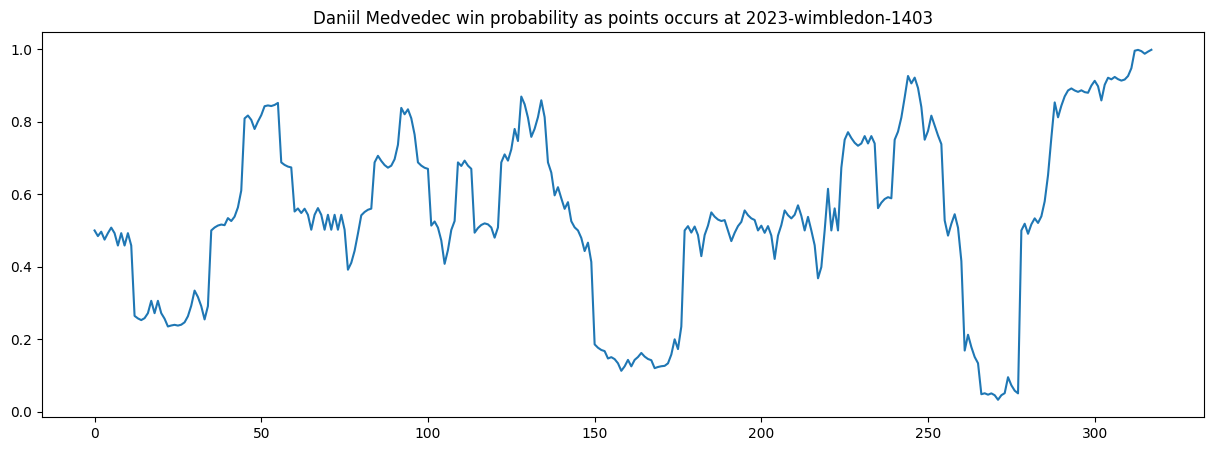

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(data_1310.index, data_1310['win_pct_bfr'].astype('float'))
plt.title('Daniil Medvedec win probability as points occurs at 2023-wimbledon-1403')

In [ ]:
data_1310['p1_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1310)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1310.loc[i,['p1_performance']].values[0] > 0 and data_1310.loc[i+1,['p1_performance']].values[0] > 0 and data_1310.loc[i+2,['p1_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1310.loc[i,['p1_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1310.loc[i,['p1_performance']].values[0] < 0:
    data_1310.loc[i,['p1_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1310.loc[i,['p1_momentum']] = 1
    current_momentum += 1
  else:
    data_1310.loc[i,['p1_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

25 13


In [ ]:
data_1310['p2_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1310)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1310.loc[i,['p2_performance']].values[0] > 0 and data_1310.loc[i+1,['p2_performance']].values[0] > 0 and data_1310.loc[i+2,['p2_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1310.loc[i,['p2_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1310.loc[i,['p2_performance']].values[0] < 0:
    data_1310.loc[i,['p2_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1310.loc[i,['p2_momentum']] = 1
    current_momentum += 1
  else:
    data_1310.loc[i,['p2_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

24 10


In [ ]:
data_1310['p1_momentum_start'] = ''
tick = False
for i in range(0,len(data_1310)-3):
  if data_1310.loc[i,['p1_performance']].values[0] > 0 and data_1310.loc[i+1,['p1_performance']].values[0] > 0 and data_1310.loc[i+2,['p1_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1310.loc[i,['p1_momentum_start']] = 1
  elif data_1310.loc[i,['p1_performance']].values[0] < 0:
    data_1310.loc[i,['p1_momentum_start']] = 0
    tick = False
  else:
    data_1310.loc[i,['p1_momentum_start']] = 0

In [ ]:
data_1310['p2_momentum_start'] = ''
tick = False
for i in range(0,len(data_1310)-3):
  if data_1310.loc[i,['p2_performance']].values[0] > 0 and data_1310.loc[i+1,['p2_performance']].values[0] > 0 and data_1310.loc[i+2,['p2_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1310.loc[i,['p2_momentum_start']] = 1
  elif data_1310.loc[i,['p2_performance']].values[0] < 0:
    data_1310.loc[i,['p2_momentum_start']] = 0
    tick = False
  else:
    data_1310.loc[i,['p2_momentum_start']] = 0

In [ ]:
data_1310['momentum_start'] = data_1310['p1_momentum_start'] + data_1310['p2_momentum_start']

In [ ]:
fig = px.scatter(data_1310, x = data_1310.index, y = 'win_pct_bfr',color = 'momentum')
fig.show()

## 2023-wimbledon-1304


In [ ]:
data_1304 = pd.read_csv('/content/drive/MyDrive/MCM 2024/data_1304.csv', index_col = 0)
data_1304

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji,win_pct_bfr
0,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,00:00:00,1,1,1,0,0,0,...,B,NCTL,D,0.61,0.39,0.65,0.37,0.711,0.731,0.388233
1,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,00:00:41,1,1,2,0,0,0,...,B,NCTL,D,0.61,0.39,0.65,0.37,0.711,0.731,0.393781
2,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,00:01:09,1,1,3,0,0,0,...,W,CTL,ND,0.61,0.39,0.65,0.37,0.711,0.731,0.397354
3,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,00:01:29,1,1,4,0,0,0,...,BW,CTL,ND,0.61,0.39,0.65,0.37,0.711,0.731,0.399086
4,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,00:02:42,1,2,5,0,0,1,...,BW,NCTL,NaN,0.61,0.39,0.65,0.37,0.711,0.731,0.410918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,04:17:00,5,13,333,2,2,6,...,BW,NCTL,ND,0.61,0.39,0.65,0.37,0.711,0.731,0.463881
333,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,04:17:52,5,13,334,2,2,6,...,C,NCTL,ND,0.61,0.39,0.65,0.37,0.711,0.731,0.463881
334,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,04:18:29,5,13,335,2,2,6,...,C,NCTL,ND,0.61,0.39,0.65,0.37,0.711,0.731,0.463881
335,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,04:19:12,5,13,336,2,2,6,...,NaN,NaN,NaN,0.61,0.39,0.65,0.37,0.711,0.731,0.463881


In [ ]:
data_1304['win_pct_after'] = data_1304['win_pct_bfr'].shift(-1)
data_1304['p1_performance'] = data_1304['win_pct_after'] - data_1304['win_pct_bfr']
data_1304['p1_perform'] = data_1304['win_pct_bfr'] - data_1304.loc[0, 'win_pct_bfr']
data_1304['opp_pct_bfr'] = 1-data_1304['win_pct_bfr']
data_1304['opp_pct_after'] = data_1304['opp_pct_bfr'].shift(-1)
data_1304['p2_performance'] = data_1304['opp_pct_after'] - data_1304['opp_pct_bfr']
data_1304['p2_perform'] = data_1304['opp_pct_bfr'] - data_1304.loc[0, 'opp_pct_bfr']

data_1304

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,fij,fji,win_pct_bfr,win_pct_after,p1_performance,p1_perform,opp_pct_bfr,opp_pct_after,p2_performance,p2_perform
0,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,00:00:00,1,1,1,0,0,0,...,0.711,0.731,0.388233,0.393781,0.005549,0.000000,0.611767,0.606219,-0.005549,0.000000
1,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,00:00:41,1,1,2,0,0,0,...,0.711,0.731,0.393781,0.397354,0.003573,0.005549,0.606219,0.602646,-0.003573,-0.005549
2,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,00:01:09,1,1,3,0,0,0,...,0.711,0.731,0.397354,0.399086,0.001732,0.009121,0.602646,0.600914,-0.001732,-0.009121
3,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,00:01:29,1,1,4,0,0,0,...,0.711,0.731,0.399086,0.410918,0.011831,0.010854,0.600914,0.589082,-0.011831,-0.010854
4,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,00:02:42,1,2,5,0,0,1,...,0.711,0.731,0.410918,0.405810,-0.005108,0.022685,0.589082,0.594190,0.005108,-0.022685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,04:17:00,5,13,333,2,2,6,...,0.711,0.731,0.463881,0.463881,0.000000,0.075649,0.536119,0.536119,0.000000,-0.075649
333,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,04:17:52,5,13,334,2,2,6,...,0.711,0.731,0.463881,0.463881,0.000000,0.075649,0.536119,0.536119,0.000000,-0.075649
334,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,04:18:29,5,13,335,2,2,6,...,0.711,0.731,0.463881,0.463881,0.000000,0.075649,0.536119,0.536119,0.000000,-0.075649
335,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,04:19:12,5,13,336,2,2,6,...,0.711,0.731,0.463881,0.463881,0.000000,0.075649,0.536119,0.536119,0.000000,-0.075649


In [ ]:
data_1304['p1_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1304)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1304.loc[i,['p1_performance']].values[0] > 0 and data_1304.loc[i+1,['p1_performance']].values[0] > 0 and data_1304.loc[i+2,['p1_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1304.loc[i,['p1_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1304.loc[i,['p1_performance']].values[0] < 0:
    data_1304.loc[i,['p1_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1304.loc[i,['p1_momentum']] = 1
    current_momentum += 1
  else:
    data_1304.loc[i,['p1_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

22 12


In [ ]:
data_1304['p2_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1304)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1304.loc[i,['p2_performance']].values[0] > 0 and data_1304.loc[i+1,['p2_performance']].values[0] > 0 and data_1304.loc[i+2,['p2_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1304.loc[i,['p2_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1304.loc[i,['p2_performance']].values[0] < 0:
    data_1304.loc[i,['p2_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1304.loc[i,['p2_momentum']] = 1
    current_momentum += 1
  else:
    data_1304.loc[i,['p2_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

21 13


In [ ]:
data_1304['p1_momentum_start'] = ''
tick = False
for i in range(0,len(data_1304)-3):
  if data_1304.loc[i,['p1_performance']].values[0] > 0 and data_1304.loc[i+1,['p1_performance']].values[0] > 0 and data_1304.loc[i+2,['p1_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1304.loc[i,['p1_momentum_start']] = 1
  elif data_1304.loc[i,['p1_performance']].values[0] < 0:
    data_1304.loc[i,['p1_momentum_start']] = 0
    tick = False
  else:
    data_1304.loc[i,['p1_momentum_start']] = 0

In [ ]:
data_1304['p2_momentum_start'] = ''
tick = False
for i in range(0,len(data_1304)-3):
  if data_1304.loc[i,['p2_performance']].values[0] > 0 and data_1304.loc[i+1,['p2_performance']].values[0] > 0 and data_1304.loc[i+2,['p2_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1304.loc[i,['p2_momentum_start']] = 1
  elif data_1304.loc[i,['p2_performance']].values[0] < 0:
    data_1304.loc[i,['p2_momentum_start']] = 0
    tick = False
  else:
    data_1304.loc[i,['p2_momentum_start']] = 0

In [ ]:
data_1304['momentum_start'] = data_1304['p1_momentum_start'] + data_1304['p2_momentum_start']

## 2023-wimbledon-1407

In [ ]:
data_1407 = pd.read_csv('/content/drive/MyDrive/MCM 2024/data_1407.csv', index_col = 0)
data_1407

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,serve_width,serve_depth,return_depth,fi,gi,fj,gj,fij,fji,win_pct_bfr
0,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,00:00:00,1,1,1,0,0,0,...,BC,CTL,ND,0.65,0.39,0.64,0.35,0.771,0.721,0.754116
1,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,00:00:32,1,1,2,0,0,0,...,B,NCTL,D,0.65,0.39,0.64,0.35,0.771,0.721,0.744393
2,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,00:01:11,1,1,3,0,0,0,...,BC,NCTL,D,0.65,0.39,0.64,0.35,0.771,0.721,0.751382
3,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,00:01:51,1,1,4,0,0,0,...,C,NCTL,ND,0.65,0.39,0.64,0.35,0.771,0.721,0.756289
4,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,00:02:15,1,1,5,0,0,0,...,B,NCTL,ND,0.65,0.39,0.64,0.35,0.771,0.721,0.758897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,03:15:09,5,10,327,2,2,5,...,BW,NCTL,ND,0.65,0.39,0.64,0.35,0.771,0.721,0.633328
327,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,03:15:30,5,10,328,2,2,5,...,C,NCTL,D,0.65,0.39,0.64,0.35,0.771,0.721,0.618246
328,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,03:16:06,5,10,329,2,2,5,...,NaN,NaN,D,0.65,0.39,0.64,0.35,0.771,0.721,0.642886
329,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,03:16:34,5,10,330,2,2,5,...,B,NCTL,D,0.65,0.39,0.64,0.35,0.771,0.721,0.701013


In [ ]:
data_1407['win_pct_after'] = data_1407['win_pct_bfr'].shift(-1)
data_1407['p1_performance'] = data_1407['win_pct_after'] - data_1407['win_pct_bfr']
data_1407['p1_perform'] = data_1407['win_pct_bfr'] - data_1407.loc[0, 'win_pct_bfr']
data_1407['opp_pct_bfr'] = 1-data_1407['win_pct_bfr']
data_1407['opp_pct_after'] = data_1407['opp_pct_bfr'].shift(-1)
data_1407['p2_performance'] = data_1407['opp_pct_after'] - data_1407['opp_pct_bfr']
data_1407['p2_perform'] = data_1407['opp_pct_bfr'] - data_1407.loc[0, 'opp_pct_bfr']

data_1407

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,fij,fji,win_pct_bfr,win_pct_after,p1_performance,p1_perform,opp_pct_bfr,opp_pct_after,p2_performance,p2_perform
0,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,00:00:00,1,1,1,0,0,0,...,0.771,0.721,0.754116,0.744393,-0.009723,0.000000,0.245884,0.255607,0.009723,0.000000
1,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,00:00:32,1,1,2,0,0,0,...,0.771,0.721,0.744393,0.751382,0.006989,-0.009723,0.255607,0.248618,-0.006989,0.009723
2,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,00:01:11,1,1,3,0,0,0,...,0.771,0.721,0.751382,0.756289,0.004907,-0.002734,0.248618,0.243711,-0.004907,0.002734
3,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,00:01:51,1,1,4,0,0,0,...,0.771,0.721,0.756289,0.758897,0.002607,0.002173,0.243711,0.241103,-0.002607,-0.002173
4,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,00:02:15,1,1,5,0,0,0,...,0.771,0.721,0.758897,0.756775,-0.002122,0.004780,0.241103,0.243225,0.002122,-0.004780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,03:15:09,5,10,327,2,2,5,...,0.771,0.721,0.633328,0.618246,-0.015082,-0.120788,0.366672,0.381754,0.015082,0.120788
327,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,03:15:30,5,10,328,2,2,5,...,0.771,0.721,0.618246,0.642886,0.024640,-0.135870,0.381754,0.357114,-0.024640,0.135870
328,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,03:16:06,5,10,329,2,2,5,...,0.771,0.721,0.642886,0.701013,0.058127,-0.111230,0.357114,0.298987,-0.058127,0.111230
329,2023-wimbledon-1407,Andrey Rublev,Alexander Bublik,03:16:34,5,10,330,2,2,5,...,0.771,0.721,0.701013,0.820532,0.119519,-0.053103,0.298987,0.179468,-0.119519,0.053103


In [ ]:
data_1407['p1_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1407)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1407.loc[i,['p1_performance']].values[0] > 0 and data_1407.loc[i+1,['p1_performance']].values[0] > 0 and data_1407.loc[i+2,['p1_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1407.loc[i,['p1_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1407.loc[i,['p1_performance']].values[0] < 0:
    data_1407.loc[i,['p1_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1407.loc[i,['p1_momentum']] = 1
    current_momentum += 1
  else:
    data_1407.loc[i,['p1_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

27 16


In [ ]:
data_1407['p2_momentum'] = ''
tick = False
total_momentum = 0
momentum_exceeded = 0
current_momentum = 0
for i in range(0,len(data_1407)-3):
  if current_momentum > 3:
    momentum_exceeded += 1
    current_momentum = -10
  if data_1407.loc[i,['p2_performance']].values[0] > 0 and data_1407.loc[i+1,['p2_performance']].values[0] > 0 and data_1407.loc[i+2,['p2_performance']].values[0] > 0 and tick == False:
    tick = True
    data_1407.loc[i,['p2_momentum']] = 1
    total_momentum += 1
    current_momentum += 1
  elif data_1407.loc[i,['p2_performance']].values[0] < 0:
    data_1407.loc[i,['p2_momentum']] = 0
    tick = False
    current_momentum = 0
  elif tick == True:
    data_1407.loc[i,['p2_momentum']] = 1
    current_momentum += 1
  else:
    data_1407.loc[i,['p2_momentum']] = 0
    current_momentum = 0

print(total_momentum, momentum_exceeded)

23 13


In [ ]:
data_1407['p1_momentum_start'] = ''
tick = False
for i in range(0,len(data_1407)-3):
  if data_1407.loc[i,['p1_performance']].values[0] > 0 and data_1407.loc[i+1,['p1_performance']].values[0] > 0 and data_1407.loc[i+2,['p1_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1407.loc[i,['p1_momentum_start']] = 1
  elif data_1407.loc[i,['p1_performance']].values[0] < 0:
    data_1407.loc[i,['p1_momentum_start']] = 0
    tick = False
  else:
    data_1407.loc[i,['p1_momentum_start']] = 0

In [ ]:
data_1407['p2_momentum_start'] = ''
tick = False
for i in range(0,len(data_1407)-3):
  if data_1407.loc[i,['p2_performance']].values[0] > 0 and data_1407.loc[i+1,['p2_performance']].values[0] > 0 and data_1407.loc[i+2,['p2_performance']].values[0] > 0 and tick == False :
    tick = True
    data_1407.loc[i,['p2_momentum_start']] = 1
  elif data_1407.loc[i,['p2_performance']].values[0] < 0:
    data_1407.loc[i,['p2_momentum_start']] = 0
    tick = False
  else:
    data_1407.loc[i,['p2_momentum_start']] = 0

In [ ]:
data_1407['momentum_start'] = data_1407['p1_momentum_start'] + data_1407['p2_momentum_start']

# **Light GBM**

In [ ]:
data_1701_mod = data_1701[:-3]
data_1701_mod.drop(['match_id', 'player1', 'player2','elapsed_time','fi','gi','fj','gj','fij','fji','win_pct_bfr','win_pct_after', 'p1_performance','p1_perform','opp_pct_bfr','opp_pct_after','p2_performance','p2_perform','p1_momentum','p2_momentum', 'p1_momentum_start', 'p2_momentum_start'],axis = 1, inplace = True)

data_1303_mod = data_1303[:-3]
data_1303_mod.drop(['match_id','player1', 'player2','elapsed_time','fi','gi','fj','gj','fij','fji','win_pct_bfr','win_pct_after', 'p1_performance','p1_perform','opp_pct_bfr','opp_pct_after','p2_performance','p2_perform','p1_momentum','p2_momentum', 'p1_momentum_start', 'p2_momentum_start'],axis = 1, inplace = True)

data_1304_mod = data_1304[:-3]
data_1304_mod.drop(['match_id','player1', 'player2','elapsed_time','fi','gi','fj','gj','fij','fji','win_pct_bfr','win_pct_after', 'p1_performance','p1_perform','opp_pct_bfr','opp_pct_after','p2_performance','p2_perform','p1_momentum','p2_momentum', 'p1_momentum_start', 'p2_momentum_start'],axis = 1, inplace = True)

data_1306_mod = data_1306[:-3]
data_1306_mod.drop(['match_id','player1', 'player2','elapsed_time','fi','gi','fj','gj','fij','fji','win_pct_bfr','win_pct_after', 'p1_performance','p1_perform','opp_pct_bfr','opp_pct_after','p2_performance','p2_perform','p1_momentum','p2_momentum', 'p1_momentum_start', 'p2_momentum_start'],axis = 1, inplace = True)

data_1310_mod = data_1310[:-3]
data_1310_mod.drop(['match_id','player1', 'player2','elapsed_time','fi','gi','fj','gj','fij','fji','win_pct_bfr','win_pct_after', 'p1_performance','p1_perform','opp_pct_bfr','opp_pct_after','p2_performance','p2_perform','p1_momentum','p2_momentum', 'p1_momentum_start', 'p2_momentum_start'],axis = 1, inplace = True)

data_1403_mod = data_1403[:-3]
data_1403_mod.drop(['match_id','player1', 'player2','elapsed_time','fi','gi','fj','gj','fij','fji','win_pct_bfr','win_pct_after', 'p1_performance','p1_perform','opp_pct_bfr','opp_pct_after','p2_performance','p2_perform','p1_momentum','p2_momentum', 'p1_momentum_start', 'p2_momentum_start'],axis = 1, inplace = True)

data_1407_mod = data_1407[:-3]
data_1407_mod.drop(['match_id','player1', 'player2','elapsed_time','fi','gi','fj','gj','fij','fji','win_pct_bfr','win_pct_after', 'p1_performance','p1_perform','opp_pct_bfr','opp_pct_after','p2_performance','p2_perform','p1_momentum','p2_momentum', 'p1_momentum_start', 'p2_momentum_start'],axis = 1, inplace = True)



A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

In [ ]:
frames = [data_1303_mod, data_1304_mod,data_1306_mod,data_1403_mod,data_1407_mod,data_1701_mod]
dataset = pd.concat(frames)
dataset

,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,p2_games,p1_score,p2_score,server,...,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth,momentum_start
0,1,1,1,0,0,0,0,0,0,2,...,0,0,8.929,6.360,2,99.0,BC,NCTL,ND,0
1,1,1,2,0,0,0,0,1,0,2,...,0,0,5.196,5.892,1,103.0,B,NCTL,D,1
2,1,1,3,0,0,0,0,1,1,2,...,0,0,28.364,27.314,7,115.0,BW,NCTL,ND,0
3,1,1,4,0,0,0,0,1,2,2,...,0,0,6.553,4.084,1,126.0,C,NCTL,ND,0
4,1,1,5,0,0,0,0,1,3,2,...,0,0,1.364,0.694,1,121.0,W,CTL,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326,5,9,327,2,2,5,3,0,3,2,...,0,0,16.135,6.657,2,123.0,C,NCTL,ND,0
327,5,9,328,2,2,5,3,1,3,2,...,0,0,4.150,3.609,1,99.0,BW,NCTL,D,0
328,5,10,329,2,2,5,4,0,0,1,...,0,0,6.772,10.303,2,127.0,C,NCTL,ND,0
329,5,10,330,2,2,5,4,0,1,1,...,0,0,38.620,50.971,11,123.0,C,NCTL,D,0


In [ ]:
dataset.isnull().any()

set_no                False
game_no               False
point_no              False
p1_sets               False
p2_sets               False
p1_games              False
p2_games              False
p1_score              False
p2_score              False
server                False
serve_no              False
point_victor          False
p1_points_won         False
p2_points_won         False
game_victor           False
set_victor            False
p1_ace                False
p2_ace                False
p1_winner             False
p2_winner             False
winner_shot_type      False
p1_double_fault       False
p2_double_fault       False
p1_unf_err            False
p2_unf_err            False
p1_net_pt             False
p2_net_pt             False
p1_net_pt_won         False
p2_net_pt_won         False
p1_break_pt           False
p2_break_pt           False
p1_break_pt_won       False
p2_break_pt_won       False
p1_break_pt_missed    False
p2_break_pt_missed    False
p1_distance_run     

In [ ]:
dataset.fillna(0, inplace = True)
dataset.isnull().sum().sum()

0

In [ ]:
dataset.dtypes

set_no                  int64
game_no                 int64
point_no                int64
p1_sets                 int64
p2_sets                 int64
p1_games                int64
p2_games                int64
p1_score                int64
p2_score                int64
server                  int64
serve_no                int64
point_victor            int64
p1_points_won           int64
p2_points_won           int64
game_victor             int64
set_victor              int64
p1_ace                  int64
p2_ace                  int64
p1_winner               int64
p2_winner               int64
winner_shot_type       object
p1_double_fault         int64
p2_double_fault         int64
p1_unf_err              int64
p2_unf_err              int64
p1_net_pt               int64
p2_net_pt               int64
p1_net_pt_won           int64
p2_net_pt_won           int64
p1_break_pt             int64
p2_break_pt             int64
p1_break_pt_won         int64
p2_break_pt_won         int64
p1_break_p

In [ ]:
from sklearn.preprocessing import LabelEncoder
Label_encoder = LabelEncoder()
for features in ['winner_shot_type','serve_width', 'serve_depth', 'return_depth']:
    dataset[features] = Label_encoder.fit_transform(dataset[features].astype('str'))

In [ ]:
dataset.dtypes

set_no                  int64
game_no                 int64
point_no                int64
p1_sets                 int64
p2_sets                 int64
p1_games                int64
p2_games                int64
p1_score                int64
p2_score                int64
server                  int64
serve_no                int64
point_victor            int64
p1_points_won           int64
p2_points_won           int64
game_victor             int64
set_victor              int64
p1_ace                  int64
p2_ace                  int64
p1_winner               int64
p2_winner               int64
winner_shot_type        int64
p1_double_fault         int64
p2_double_fault         int64
p1_unf_err              int64
p2_unf_err              int64
p1_net_pt               int64
p2_net_pt               int64
p1_net_pt_won           int64
p2_net_pt_won           int64
p1_break_pt             int64
p2_break_pt             int64
p1_break_pt_won         int64
p2_break_pt_won         int64
p1_break_p

In [ ]:
from sklearn.preprocessing import MinMaxScaler
features = [features for features in dataset.columns.drop(['momentum_start'])]
scaler = MinMaxScaler()
dataset[features] = scaler.fit_transform(dataset[features])

dataset.head()

,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,p2_games,p1_score,p2_score,server,...,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth,momentum_start
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,...,0.0,0.0,0.073757,0.050451,0.066667,0.717391,0.4,1.0,1.0,0
1,0.0,0.0,0.003003,0.0,0.0,0.0,0.0,0.111111,0.0,1.0,...,0.0,0.0,0.042921,0.046739,0.033333,0.746377,0.2,1.0,0.5,1
2,0.0,0.0,0.006006,0.0,0.0,0.0,0.0,0.111111,0.1,1.0,...,0.0,0.0,0.234297,0.216671,0.233333,0.833333,0.6,1.0,1.0,0
3,0.0,0.0,0.009009,0.0,0.0,0.0,0.0,0.111111,0.2,1.0,...,0.0,0.0,0.054130,0.032397,0.033333,0.913043,0.8,1.0,1.0,0
4,0.0,0.0,0.012012,0.0,0.0,0.0,0.0,0.111111,0.3,1.0,...,0.0,0.0,0.011267,0.005505,0.033333,0.876812,1.0,0.5,0.0,0


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
X = dataset.drop(['momentum_start'], axis = 1)
y = dataset['momentum_start']

encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)

train_X, test_X, train_y, test_y = train_test_split(X, y, random_state=42, shuffle = True)

d_train = lgb.Dataset(train_X, label=train_y)
d_test = lgb.Dataset(test_X, label=test_y)

params = {
    "max_bin": 8192,
    "learning_rate": 0.05,
    "boosting_type": "gbdt",
    "objective": "multiclass",
    "num_classes": 3,
    "metric": "multi_logloss",
    "num_leaves": 10,
    "verbose": -1,
    "min_data": 100,
    "boost_from_average": True,
    "early_stopping_round": 50,
}
lgb_model = lgb.train(
    params,
    d_train,
    10000,
    valid_sets=[d_test],
)

lgb_pred = encoder.inverse_transform(np.argmax(lgb_model.predict(test_X), axis = 1))
test_y = encoder.inverse_transform(test_y)

f1_score_lgb = f1_score(test_y, lgb_pred, average = 'micro')
f1_score_lgb

0.8702290076335878

In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.7/535.7 kB 8.2 MB/s eta 0:00:00


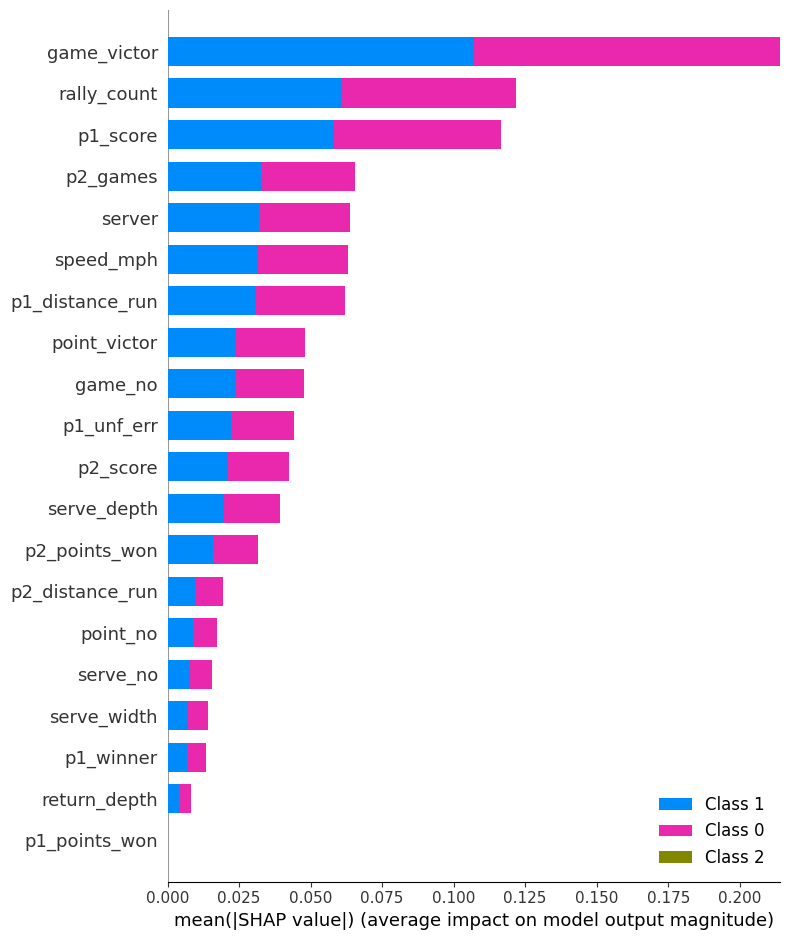

In [ ]:
import shap
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(test_X)
fig: plt.Figure = plt.figure(1)
shap.summary_plot(shap_values, train_X, plot_type="bar", show=True)

# **Testing on Different Matches**

In [ ]:
data_1310_mod

,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,p2_games,p1_score,p2_score,server,...,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth,momentum_start
0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,...,0.0,0.0,0.216255,0.209909,0.0,NaN,0.4,0.5,0.0,0.0
1,0.0,0.000000,0.003185,0.0,0.0,0.000000,0.000000,0.000000,0.166667,1.0,...,0.0,0.0,0.025840,0.016732,0.0,NaN,0.0,0.0,1.0,0.0
2,0.0,0.000000,0.006369,0.0,0.0,0.000000,0.000000,0.166667,0.166667,1.0,...,0.0,0.0,0.182522,0.160757,0.0,NaN,0.4,0.5,0.5,0.0
3,0.0,0.000000,0.009554,0.0,0.0,0.000000,0.000000,0.166667,0.333333,1.0,...,0.0,0.0,0.169843,0.219006,0.0,NaN,0.4,0.5,0.5,0.0
4,0.0,0.000000,0.012739,0.0,0.0,0.000000,0.000000,0.333333,0.333333,1.0,...,0.0,0.0,0.264411,0.217536,0.0,NaN,0.6,0.5,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,1.0,0.416667,0.987261,1.0,1.0,0.666667,0.166667,0.500000,0.500000,1.0,...,0.0,0.0,0.464899,0.406213,0.0,NaN,0.4,0.5,0.0,0.0
311,1.0,0.416667,0.990446,1.0,1.0,0.666667,0.166667,0.500000,0.333333,1.0,...,0.0,0.0,0.010453,0.006664,0.0,NaN,0.4,0.0,1.0,0.0
312,1.0,0.500000,0.993631,1.0,1.0,0.833333,0.166667,0.000000,0.000000,0.0,...,0.0,0.0,0.286430,0.249416,0.0,NaN,0.4,0.0,0.0,0.0
313,1.0,0.500000,0.996815,1.0,1.0,0.833333,0.166667,0.166667,0.000000,0.0,...,0.0,0.0,0.036200,0.021183,0.0,NaN,0.4,0.5,0.0,0.0


In [ ]:
data_1310_mod.isnull().any()

set_no                False
game_no               False
point_no              False
p1_sets               False
p2_sets               False
p1_games              False
p2_games              False
p1_score              False
p2_score              False
server                False
serve_no              False
point_victor          False
p1_points_won         False
p2_points_won         False
game_victor           False
set_victor            False
p1_ace                False
p2_ace                False
p1_winner             False
p2_winner             False
winner_shot_type      False
p1_double_fault       False
p2_double_fault       False
p1_unf_err            False
p2_unf_err            False
p1_net_pt             False
p2_net_pt             False
p1_net_pt_won         False
p2_net_pt_won         False
p1_break_pt           False
p2_break_pt           False
p1_break_pt_won       False
p2_break_pt_won       False
p1_break_pt_missed    False
p2_break_pt_missed    False
p1_distance_run     

In [ ]:
data_1310_mod.fillna(0, inplace = True)
data_1310_mod.isnull().sum().sum()


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


0

In [ ]:
data_1310_mod.dtypes

set_no                  int64
game_no                 int64
point_no                int64
p1_sets                 int64
p2_sets                 int64
p1_games                int64
p2_games                int64
p1_score                int64
p2_score                int64
server                  int64
serve_no                int64
point_victor            int64
p1_points_won           int64
p2_points_won           int64
game_victor             int64
set_victor              int64
p1_ace                  int64
p2_ace                  int64
p1_winner               int64
p2_winner               int64
winner_shot_type       object
p1_double_fault         int64
p2_double_fault         int64
p1_unf_err              int64
p2_unf_err              int64
p1_net_pt               int64
p2_net_pt               int64
p1_net_pt_won           int64
p2_net_pt_won           int64
p1_break_pt             int64
p2_break_pt             int64
p1_break_pt_won         int64
p2_break_pt_won         int64
p1_break_p

In [ ]:
Label_encoder = LabelEncoder()
for features in ['winner_shot_type','serve_width', 'serve_depth', 'return_depth']:
    data_1310_mod[features] = Label_encoder.fit_transform(data_1310_mod[features].astype('str'))


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

In [ ]:
data_1310_mod.dtypes

set_no                  int64
game_no                 int64
point_no                int64
p1_sets                 int64
p2_sets                 int64
p1_games                int64
p2_games                int64
p1_score                int64
p2_score                int64
server                  int64
serve_no                int64
point_victor            int64
p1_points_won           int64
p2_points_won           int64
game_victor             int64
set_victor              int64
p1_ace                  int64
p2_ace                  int64
p1_winner               int64
p2_winner               int64
winner_shot_type        int64
p1_double_fault         int64
p2_double_fault         int64
p1_unf_err              int64
p2_unf_err              int64
p1_net_pt               int64
p2_net_pt               int64
p1_net_pt_won           int64
p2_net_pt_won           int64
p1_break_pt             int64
p2_break_pt             int64
p1_break_pt_won         int64
p2_break_pt_won         int64
p1_break_p

In [ ]:
features = [features for features in data_1310_mod.columns]
scaler = MinMaxScaler()
data_1310_mod[features] = scaler.fit_transform(data_1310_mod[features])

data_1310_mod.head()


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,p2_games,p1_score,p2_score,server,...,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth,momentum_start
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,1.0,...,0.0,0.0,0.216255,0.209909,0.0,0.0,0.4,0.5,0.0,0.0
1,0.0,0.0,0.003185,0.0,0.0,0.0,0.0,0.000000,0.166667,1.0,...,0.0,0.0,0.025840,0.016732,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.006369,0.0,0.0,0.0,0.0,0.166667,0.166667,1.0,...,0.0,0.0,0.182522,0.160757,0.0,0.0,0.4,0.5,0.5,0.0
3,0.0,0.0,0.009554,0.0,0.0,0.0,0.0,0.166667,0.333333,1.0,...,0.0,0.0,0.169843,0.219006,0.0,0.0,0.4,0.5,0.5,0.0
4,0.0,0.0,0.012739,0.0,0.0,0.0,0.0,0.333333,0.333333,1.0,...,0.0,0.0,0.264411,0.217536,0.0,0.0,0.6,0.5,0.0,0.0


In [ ]:
train_data = data_1310_mod.drop['']
lgb_test_pred = encoder.inverse_transform(np.argmax(lgb_model.predict(data_1310_mod), axis = 1))
lgb_test_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])